In [40]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:80% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:14pt;}
div.output {font-size:14pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:14pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:14px;}
</style>
"""))

<font size="6" color="green">ch12.데이터 시각화</font>
- 시각화 라이브러리 : matplotlib, Seaborn, folium(지도시각화)

- matplotlib : 파이썬에서 가장 기본적으로 사용하는 시각화 라이브러리. 판다스 내부에 포함
- seaborn : matplotlib 기반으로 다양한 색, 테마, 차트 기능과 groupby기능을 추가한 라이브러리
- folium : 

# 1절. matplotlib
- api 참조 url : https://matplotlib.org/stable/api/index.html

## 1.1 패키지 import 및 기본 설정


In [3]:
import matplotlib
matplotlib.__version__

'3.7.0'

In [9]:
import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt
# 시각화한 그래프를 저장할 때, 해상도 높이기
%config InlineBackend.figure_format = 'retina'

# 한글 설정(win/Mac OS)

# warning 경고 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게

import seaborn as sns

## 1.2 그래프 그리기
- matplolib으로 그래프를 그리기 위한 단게
    1) 데이터 준비
    2) 그래프 생성
    3) 그래프 함수로 그리기
    4) 그래프 커스터마이징
    5) 그래프 출력 및 저장

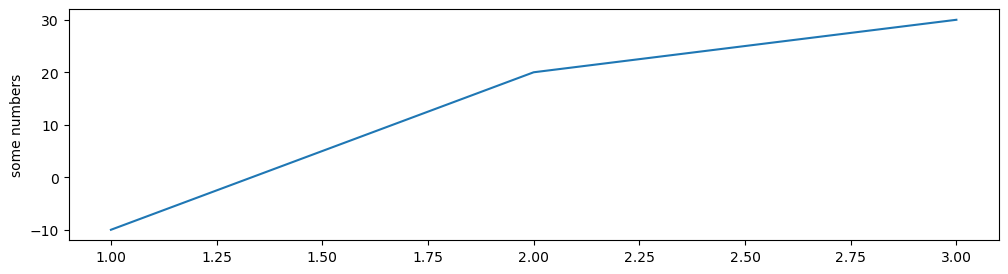

In [8]:
x = [1, 2, 3] # 1) 데이터 준비
y = [-10, 20, 30]
plt.figure(figsize=(12, 3)) # 2) 원하는 사이즈의 그래프 객체 생성
plt.plot(x, y) # 3) 그래프 함수로 그리기
plt.ylabel('some numbers') # 4) 커스터마이징
plt.savefig('Data/ch12_plot.png', bbox_inches='tight') # 5) 그래프 저장
plt.show() # 그래프 출력

## 1.3 그래프 영역 나누기
### 1) subplot()함수로 서브플롯 추가

In [11]:
import numpy as np
x = np.linspace(0, 9.9, 100)
x.shape

(100,)

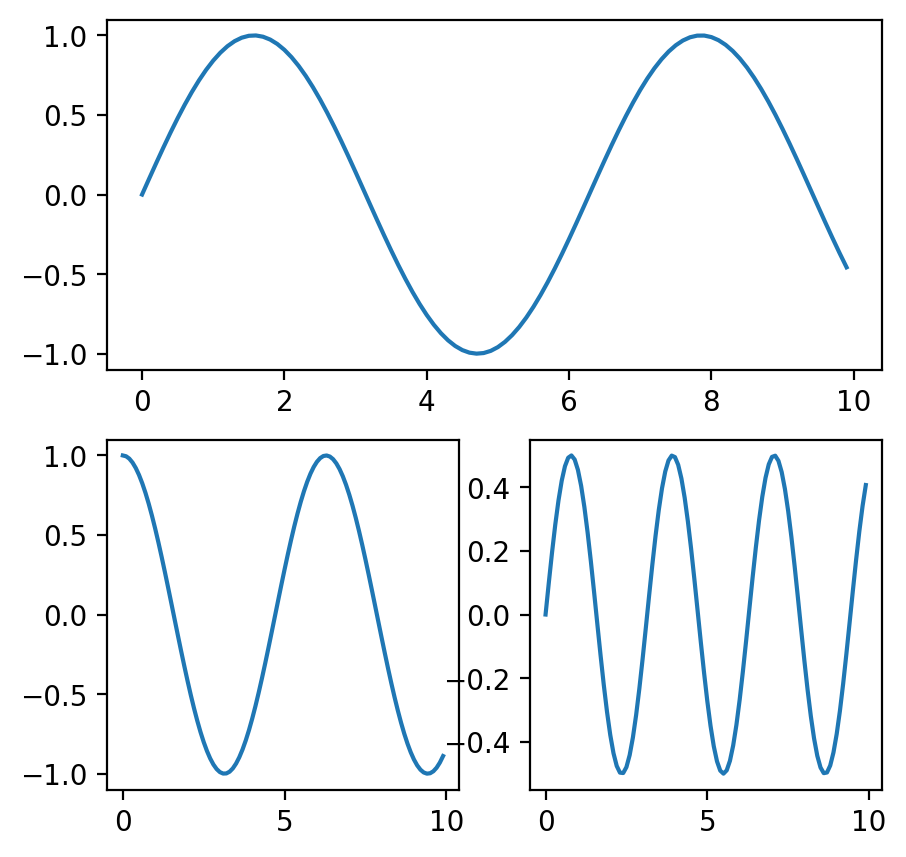

In [12]:
# plt.figure(figsize=(5,5)) : 그래프 사이즈가 이번 셀만 적용
plt.rcParams['figure.figsize'] = (5, 5) # 그래프 사이즈 셋팅(다음셀도 적용)
plt.subplot(2, 1, 1) # 2행 1열의 subplot에서 1번째 subplot을 다음과 같이 그림.
plt.plot(x, np.sin(x))
plt.subplot(2, 2, 3) # 2행 2열의 subplot에서 3번째 subplot을 다음과 같이 그림
plt.plot(x, np.cos(x))
# plt.subplot(2, 2, 4)
plt.subplot(224)
plt.plot(x, np.sin(x)*np.cos(x))
plt.show()

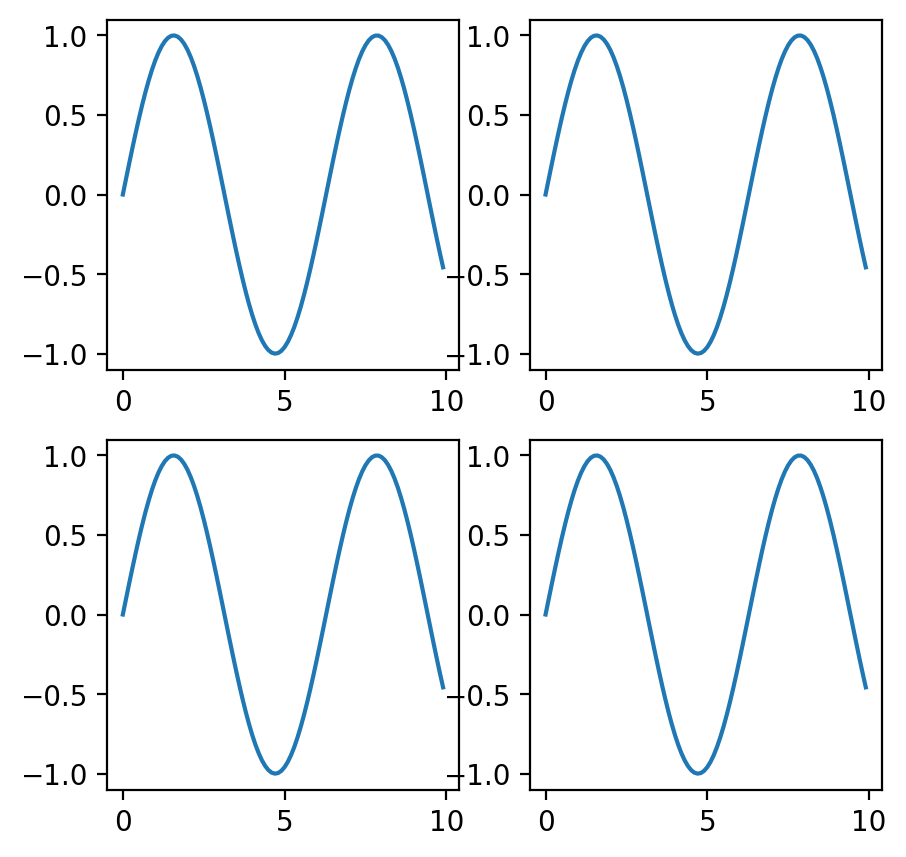

In [21]:
plt.subplot(221); plt.plot(x, np.sin(x))
plt.subplot(222); plt.plot(x, np.sin(x))
plt.subplot(223); plt.plot(x, np.sin(x))
plt.subplot(2, 2, 4); plt.plot(x, np.sin(x))
plt.show()

### 2) subplots() 함수로 서브플롯 생성
- plot함수에서 색상이나 스타일을 조정 : https://wikidocs.net/92085

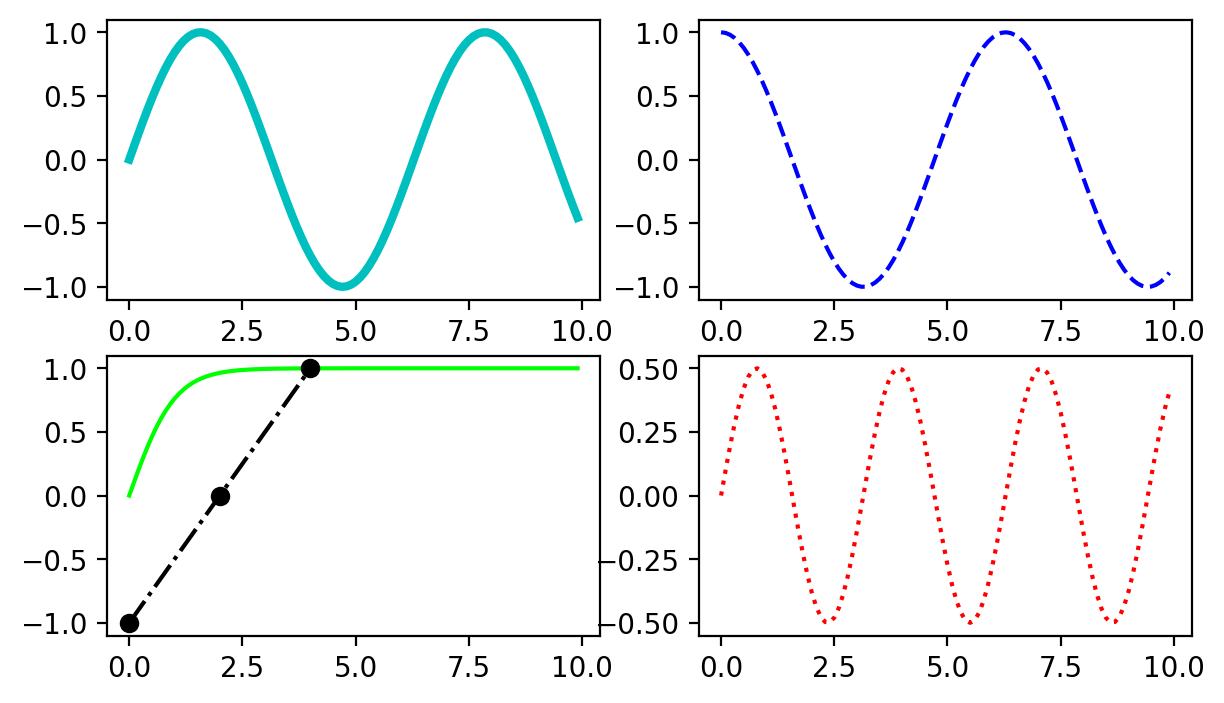

In [32]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7,4))
axes[0, 0].plot(x, np.sin(x), c='c', lw=3) # color='c', linewidth=3
axes[0, 1].plot(x, np.cos(x), 'b--') # color='b', linestyle='--' (대시라인), :(점선)
axes[1, 0].plot(x, np.tanh(x), '#00ff00') # c='#00ff00'
axes[1, 0].plot([0, 2, 4], [-1, 0, 1], 'ko-.') # c='k', marker='o', linestyle='-.'
axes[1, 1].plot(x, np.sin(x)*np.cos(x), 'r:')

#### 1행 4열 서브플롯 (for문)

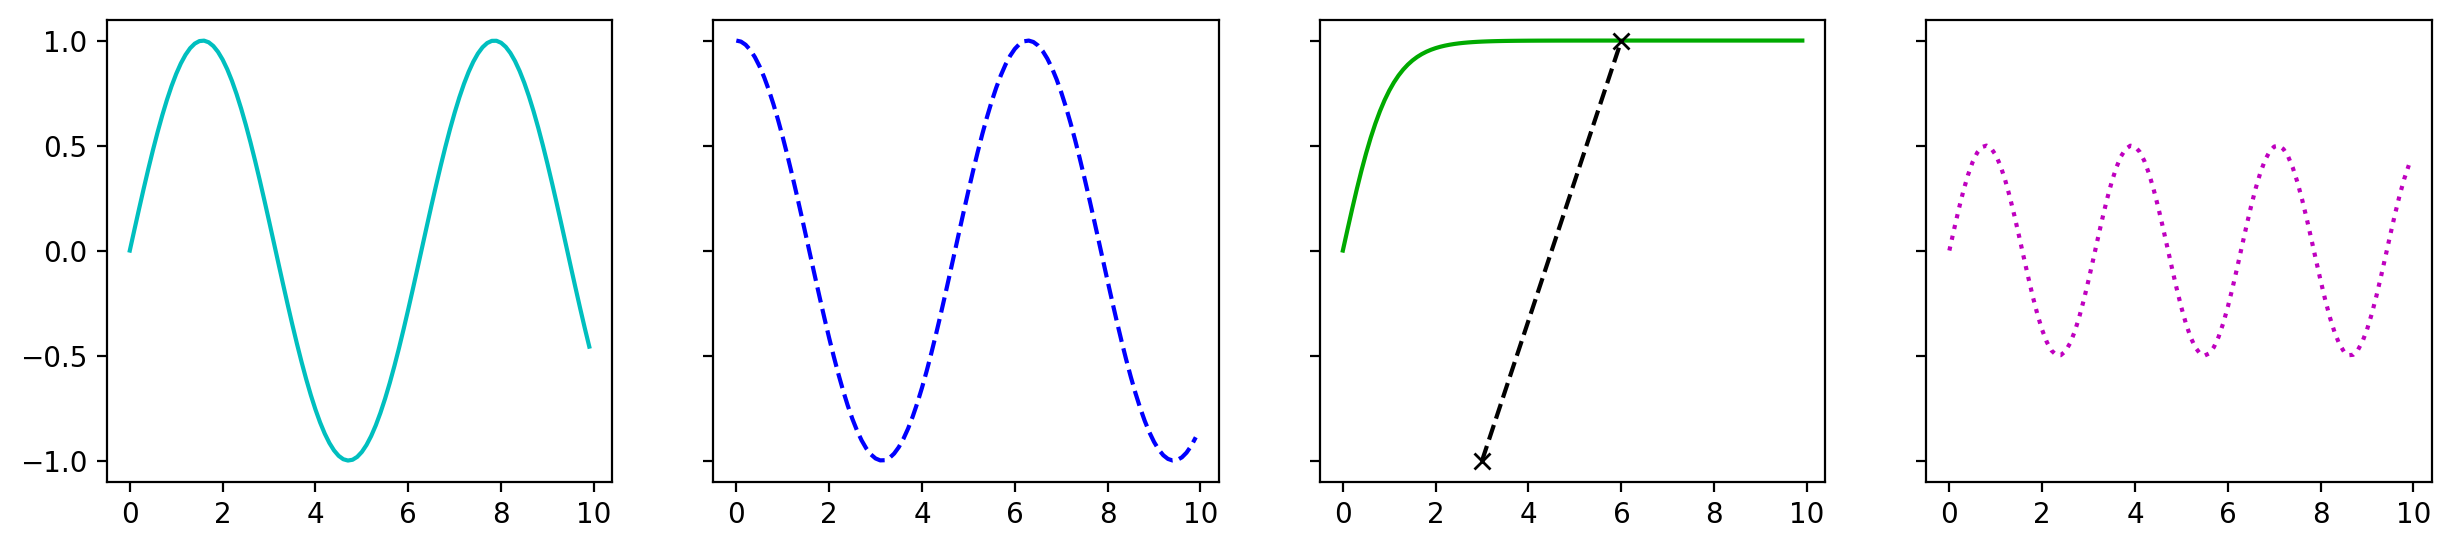

In [42]:
func_list = [np.sin, np.cos, np.tanh, lambda x:np.sin(x)*np.cos(x)]
fmt_list = ['c', 'b--', '#00AA00', 'm:']
fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharey=True) # y축 공유
for i, ax in enumerate(axes):
    ax.plot(x, func_list[i](x), fmt_list[i])
axes[2].plot([3, 6], [-1, 1], 'kx--')

##  1. 4 다양한 그래프 그리기
### 1) pyplot 함수들 (교안 16.)
- https://matplotlib.org/api/_as_gen/matplotlib.pyplot.html

### 2) matplotlib.pyplot.plot() : 선그래프
- c, color(칼라) : https://wikidocs.net/92085
-  marker = o, ^, x, s(■)
- linestyle = -(실선), --(대시라인), :(점선), -.(대시,점)

### 3) pandas.DataFrame.plot()
- plt.plot(x, y, fmt)
- df.plot(x=None, y=None, kind'line', figsize=None, grid=None, xlim, ylim...)
    * kind : line(기본값), scatter(점도표), bar(막대), barh(가로막대), box, density=kde밀도추정, hist(빈도)...
    * figsize : tuple(인치단위)
    * xlim, ylim(축의 범위) : list / tuple

In [44]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.sample(2)

,sepal_length,sepal_width,petal_length,petal_width,species
66,5.6,3.0,4.5,1.5,versicolor
18,5.7,3.8,1.7,0.3,setosa


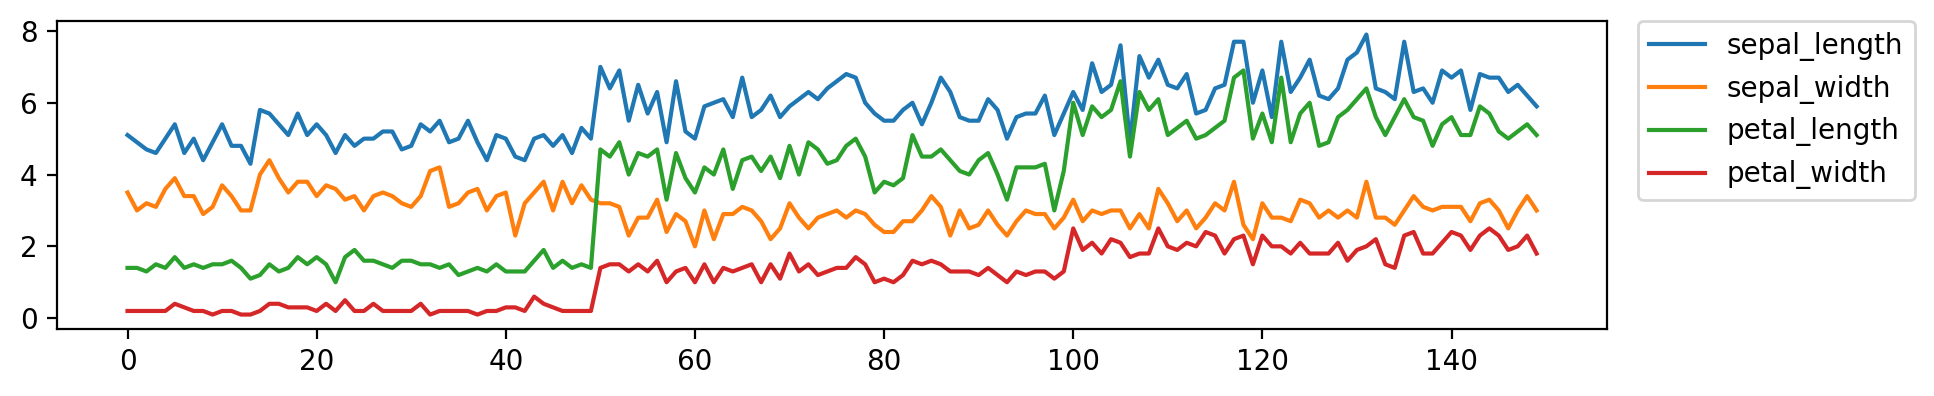

In [47]:
# 이렇게 안하고 아래처럼 사용함
plt.rcParams['figure.figsize'] = (10, 2)
plt.plot(iris.index, iris.iloc[:, :-1])
# plt.legend(iris.columns[:-1])
plt.legend(iris.columns[:-1], bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.)
plt.show()

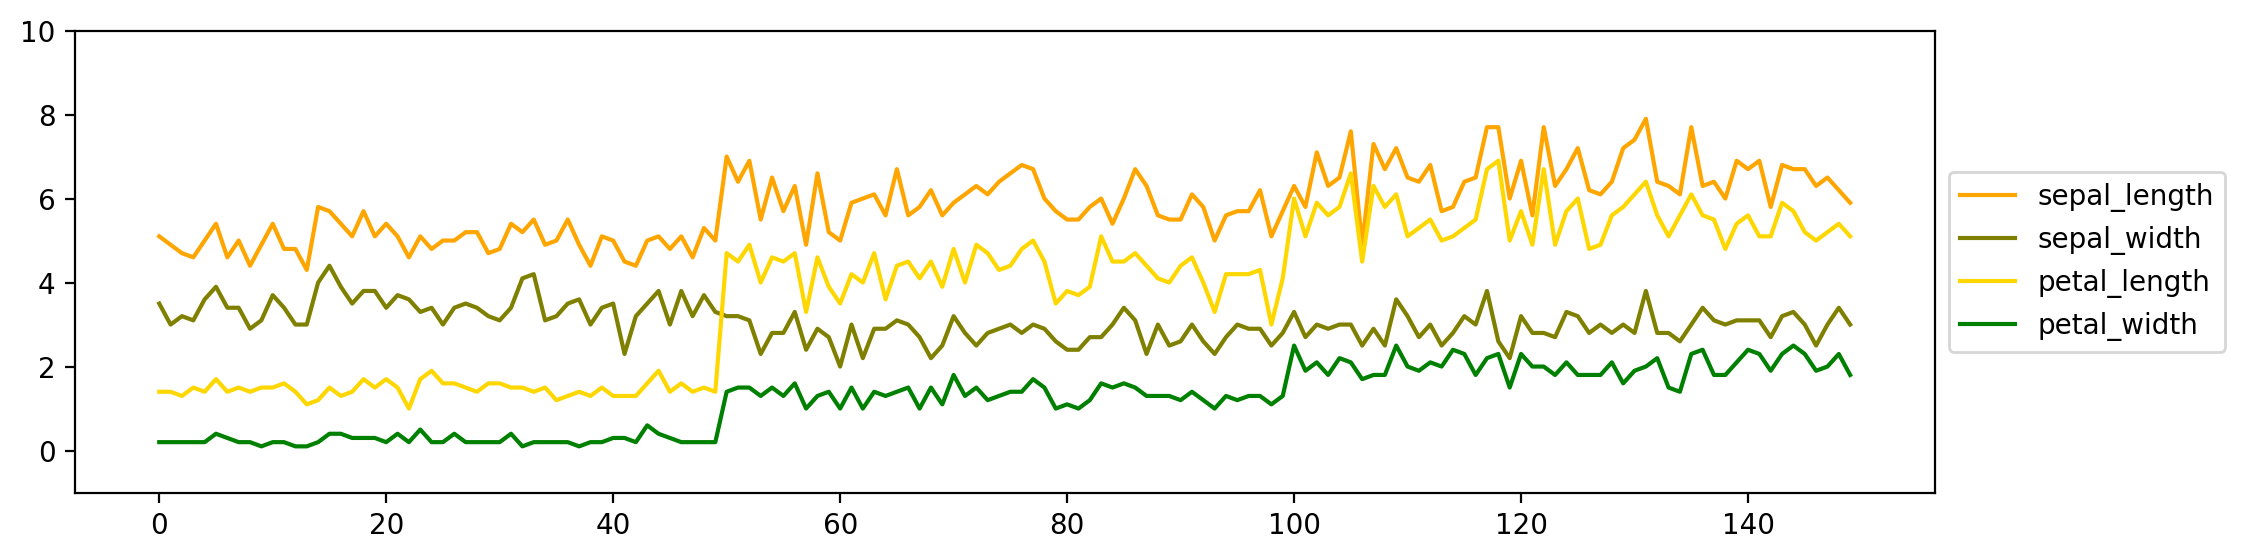

In [53]:
g = iris.plot(kind='line', # 그래프 종류
         figsize=(12, 3), # 크기
         color=['orange', 'olive', 'gold', 'green'], # 그래프 색상
         ylim=[-1, 10] # y축의 범위
         )
g.legend(loc='center left', bbox_to_anchor=(1, 0.5))

- 교안(21p.)
    - https://ko.wikipedia.org/wiki/%EC%83%81%EC%9E%90_%EC%88%98%EC%97%BC_%EA%B7%B8%EB%A6%BC
    - https://matplotlib.org/stable/tutorials/colors/colormaps.html

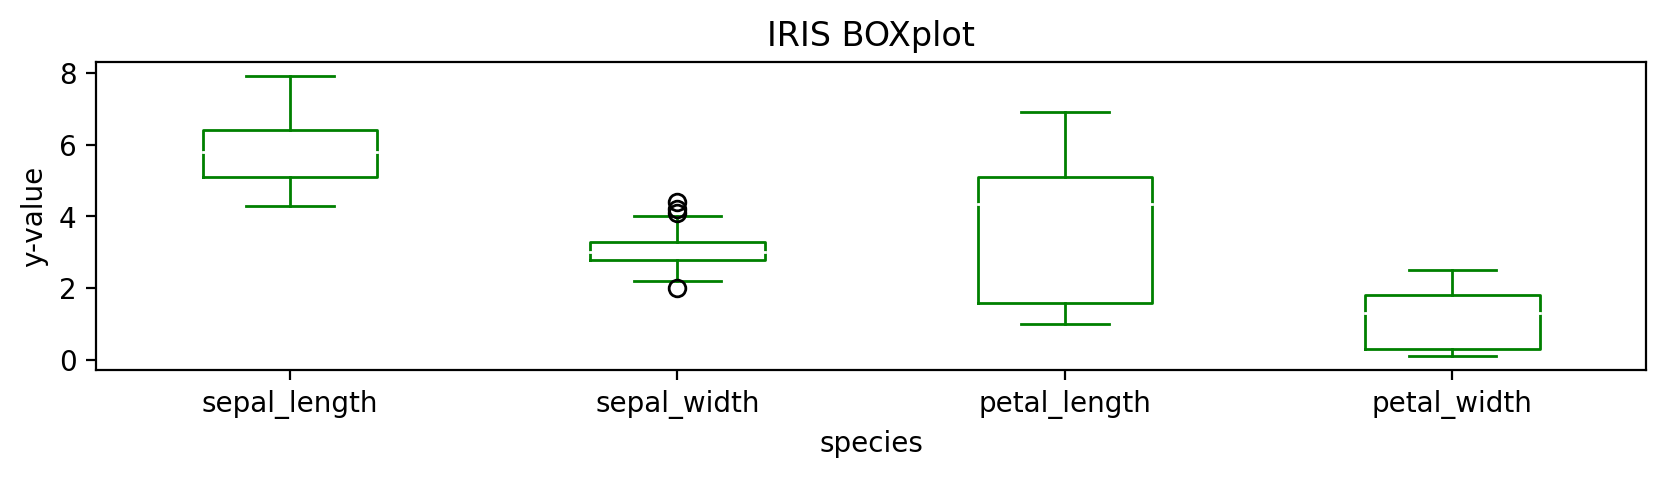

In [63]:
iris.plot(kind='box', 
          colormap='ocean',
          title='IRIS BOXplot',
          ylabel='y-value',
          xlabel='species',
          fontsize=10
          )
plt.show()

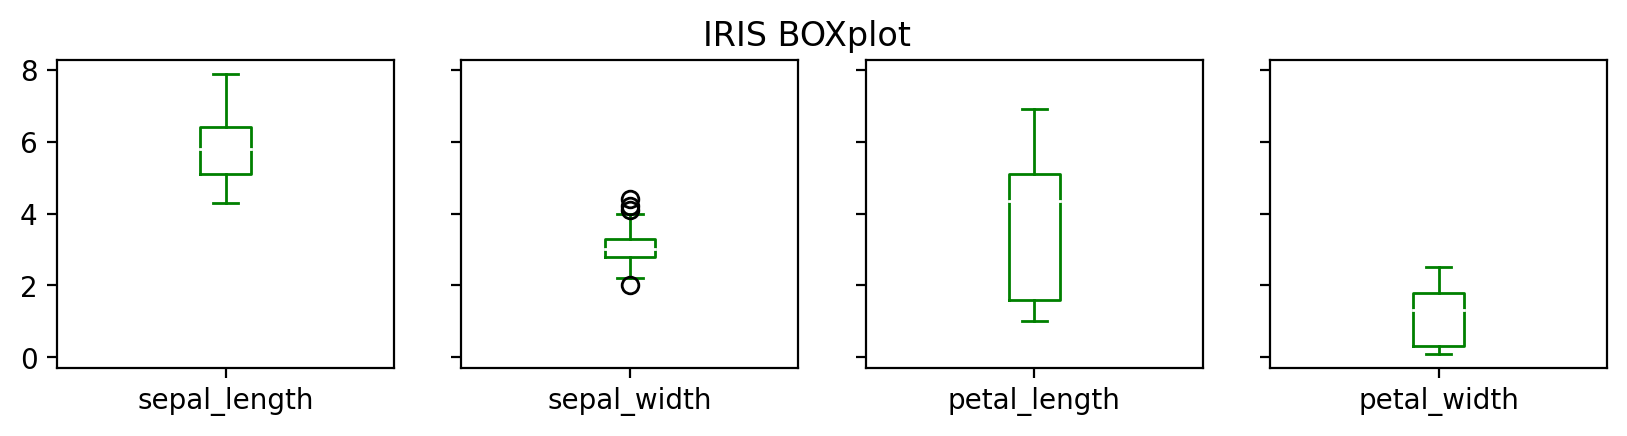

In [62]:
iris.plot(kind='box', 
          colormap='ocean',
          title='IRIS BOXplot',
          subplots=True,
          sharey=True
          )
plt.show()

In [64]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


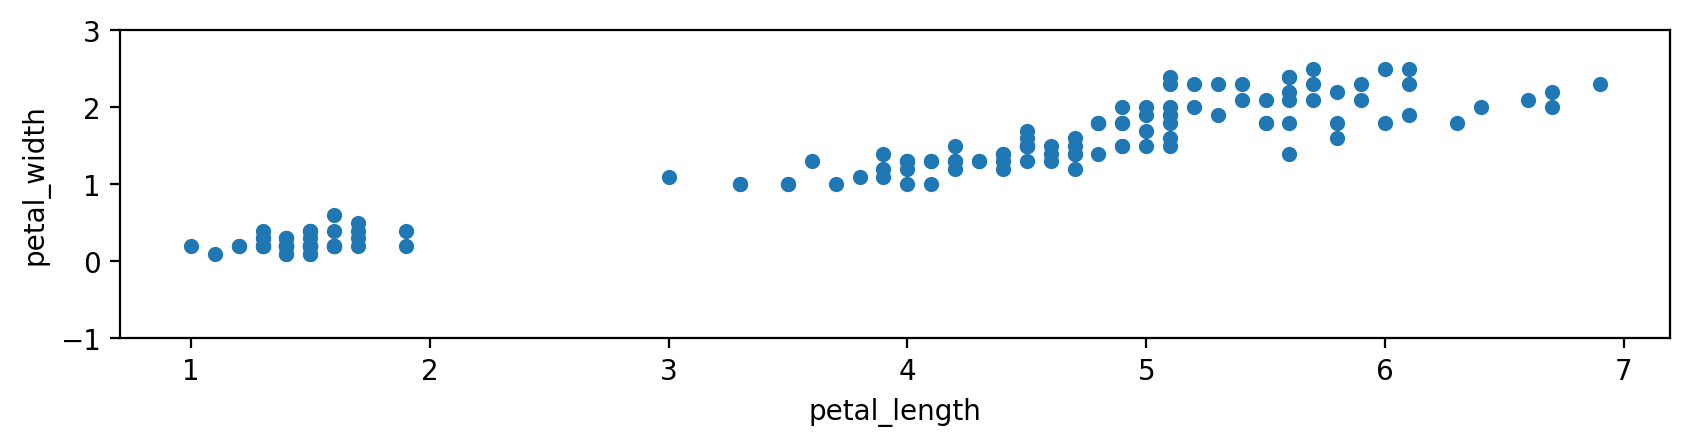

In [65]:
iris.plot(kind='scatter', x='petal_length', y='petal_width', ylim=[-1, 3]) # y축 번위 조정
plt.show()

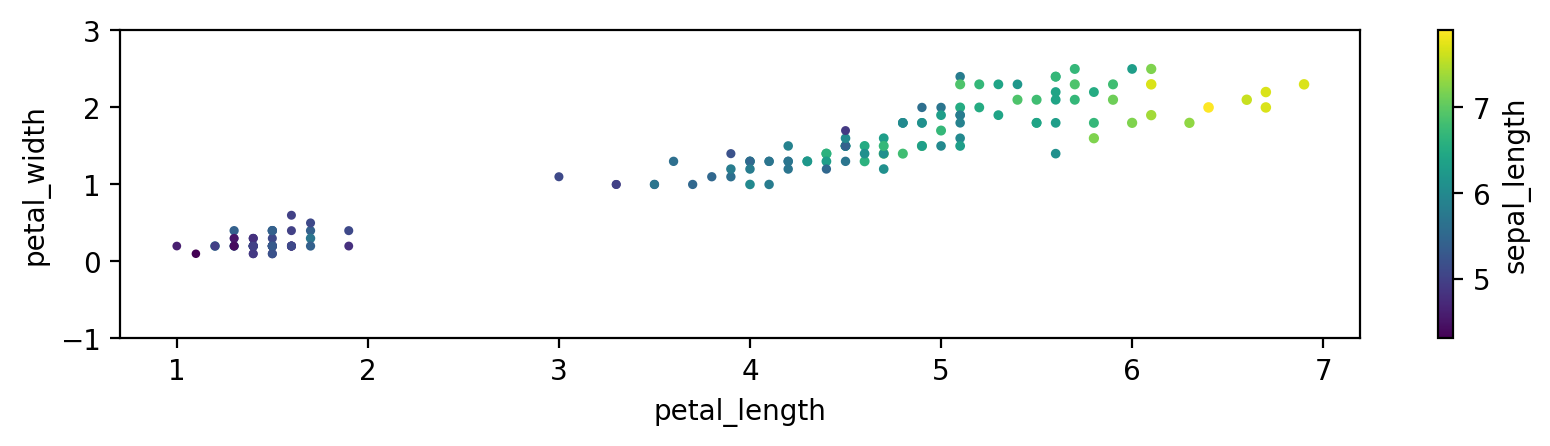

In [66]:
iris.plot(kind='scatter', x='petal_length', y='petal_width',
         s='sepal_length', # 점의 size
         c='sepal_length', # 점의 color
         ylim=[-1, 3]) # y축 범위 조정
plt.show()

#### # 종별 boxplot

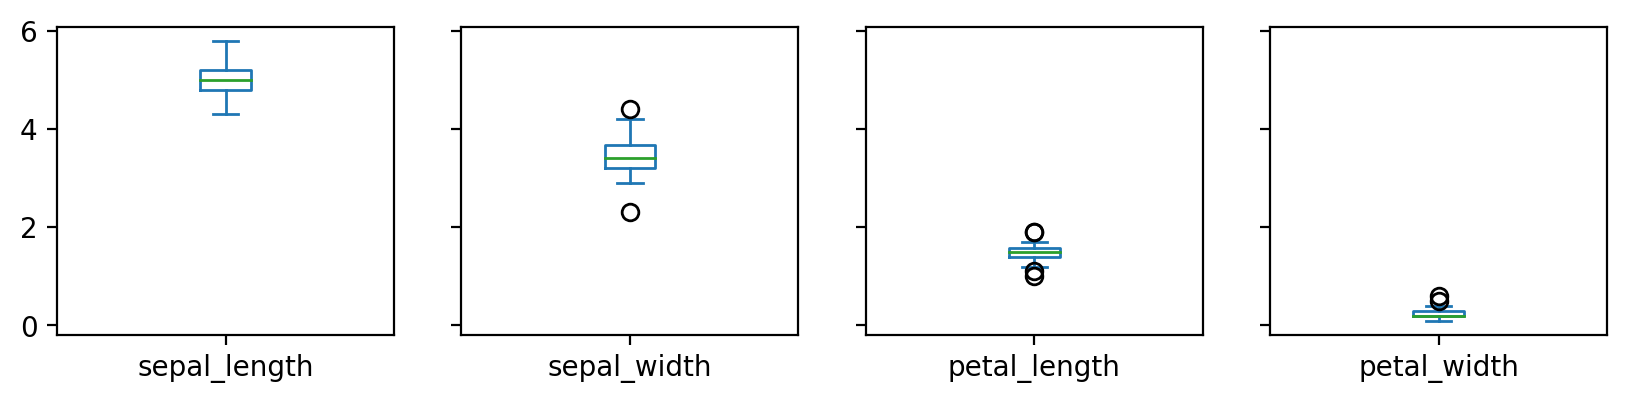

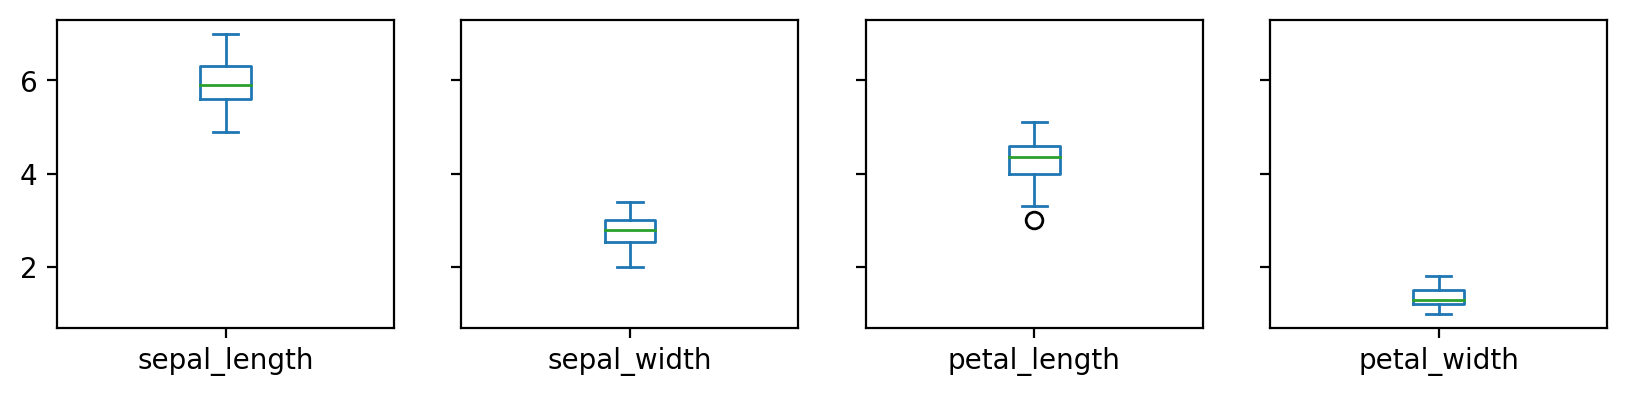

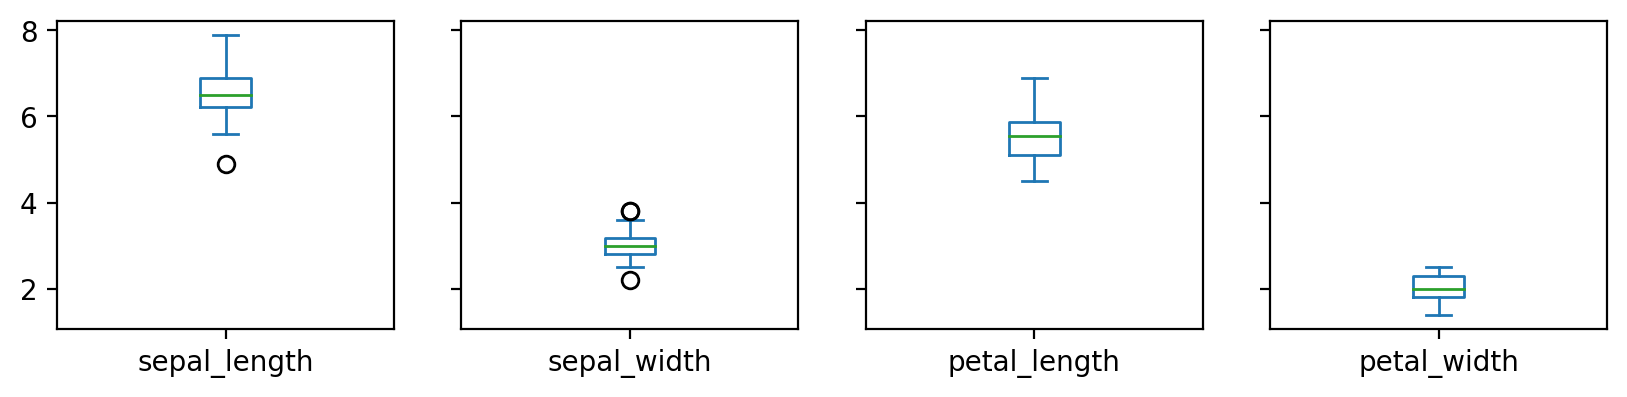

In [69]:
iris.groupby('species').plot(kind='box',
                            subplots=True,
                            sharey=True,
                            #layout=(3,4)
                            )
plt.show()

### 4) plt.scatter() : 산점도
- x, y 축이 수치형

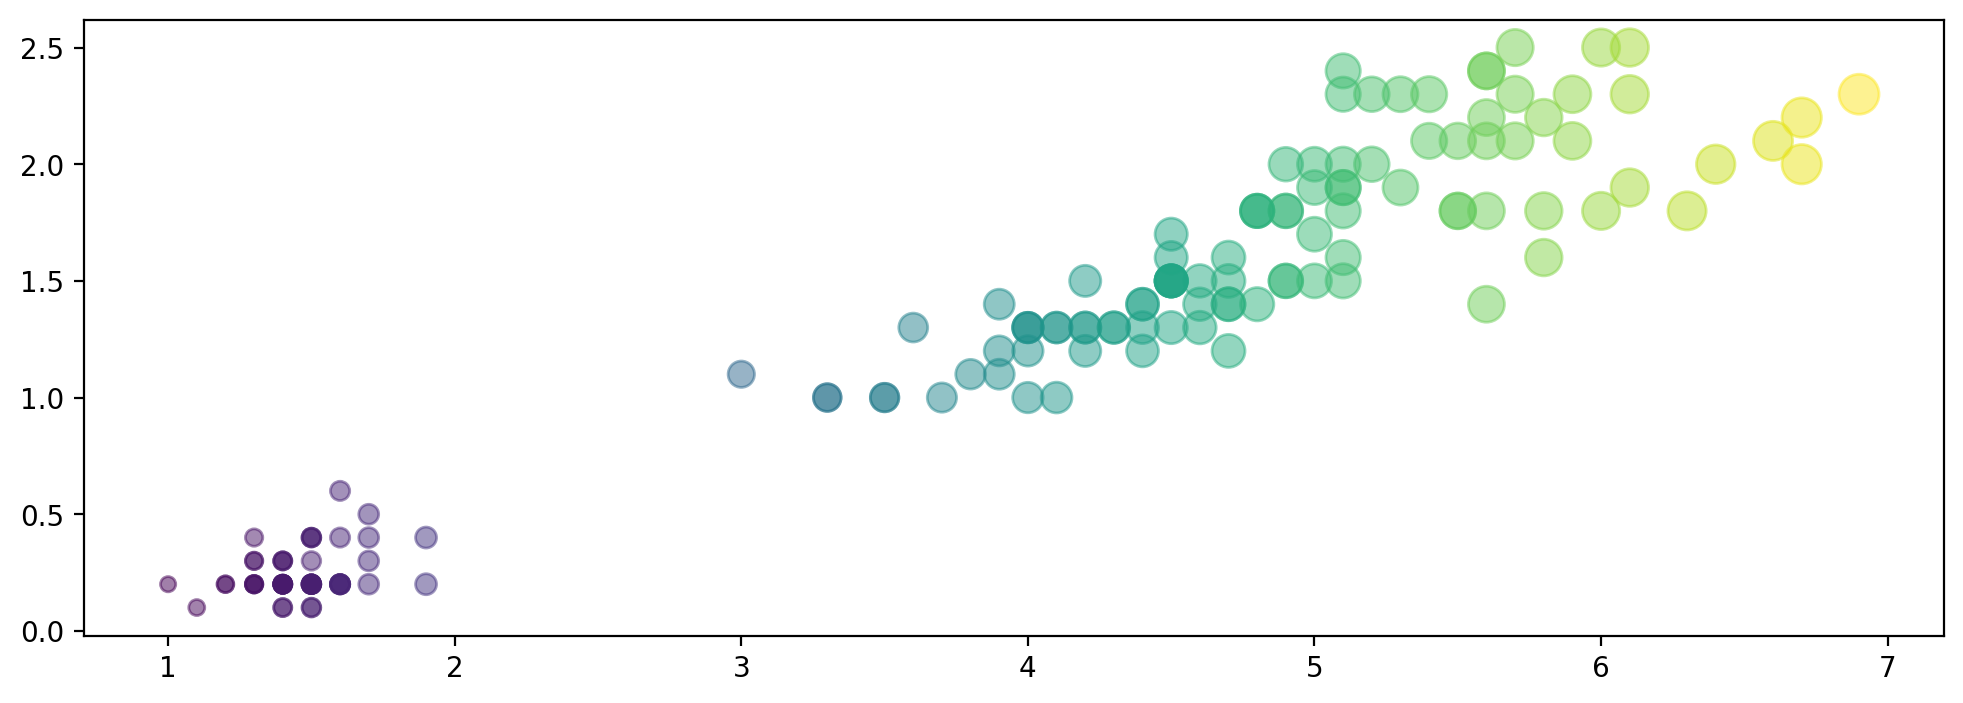

In [74]:
plt.figure(figsize=(12, 4))
plt.scatter(iris.petal_length, iris.petal_width,
            s=iris.petal_length*30, # 점의 크기
            c=iris.petal_length*20,
            alpha=0.5 #투명도(투명0, 불투명1)
            )
plt.show()

## 1.5 그 외 그래프 그리기
 ### 1) boxplot(분포를 몰라), violinplot(분포를 보여줌

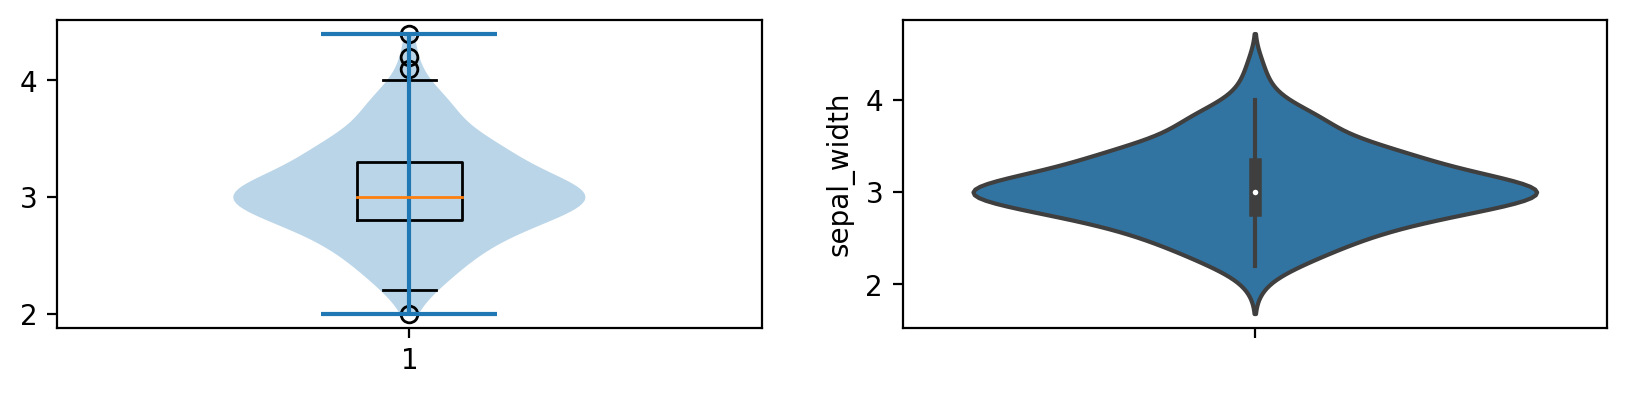

In [78]:
fig, axes = plt.subplots(ncols=2)
axes[0].boxplot(iris.sepal_width)
axes[0].violinplot(iris.sepal_width)

# sns.violinplot(y=iris.sepal_width, ax=axes[1])

axes[1].violinplot(iris.sepal_width)
plt.show()

### 2) bar, barh, axvline, axhline
- bar (Bar Chart) : 새로 방향의 막대 그래프를 생성하는 함수
- barh (Horizontal Bar chart) : 가로형 막대 그래프
- axvline :
- axhline :

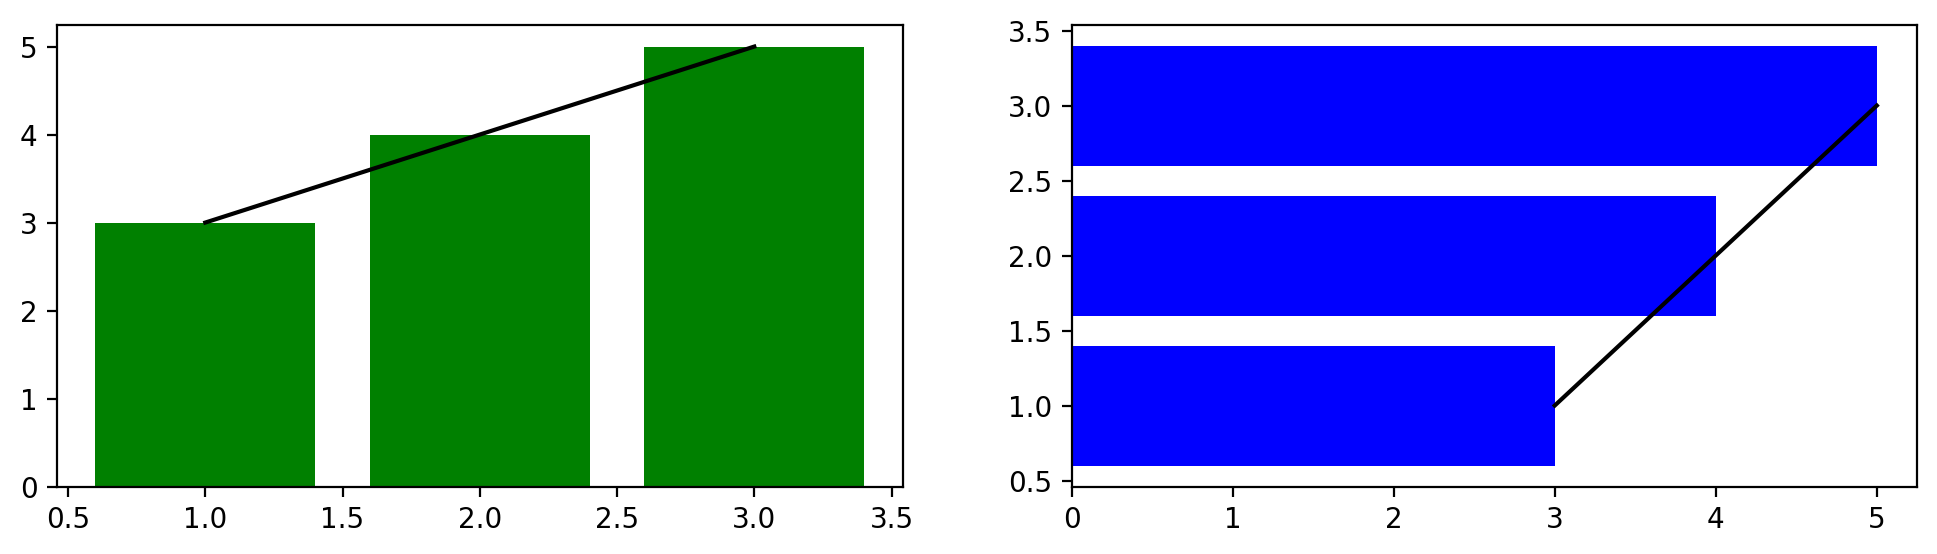

In [80]:
x = [1, 2, 3]
y = [3, 4, 5]
fig, axes = plt.subplots(ncols=2, figsize=(12, 3))
axes[0].bar(x, y, color='g')
axes[0].plot(x, y, c='k')
axes[1].barh(x, y, color='b') # 가로막대 그래프는 x와 y가 바뀜
axes[1].plot(y, x, 'k')
plt.show()

###  3) hist 히스토그램. 도수분포표를 그래프화

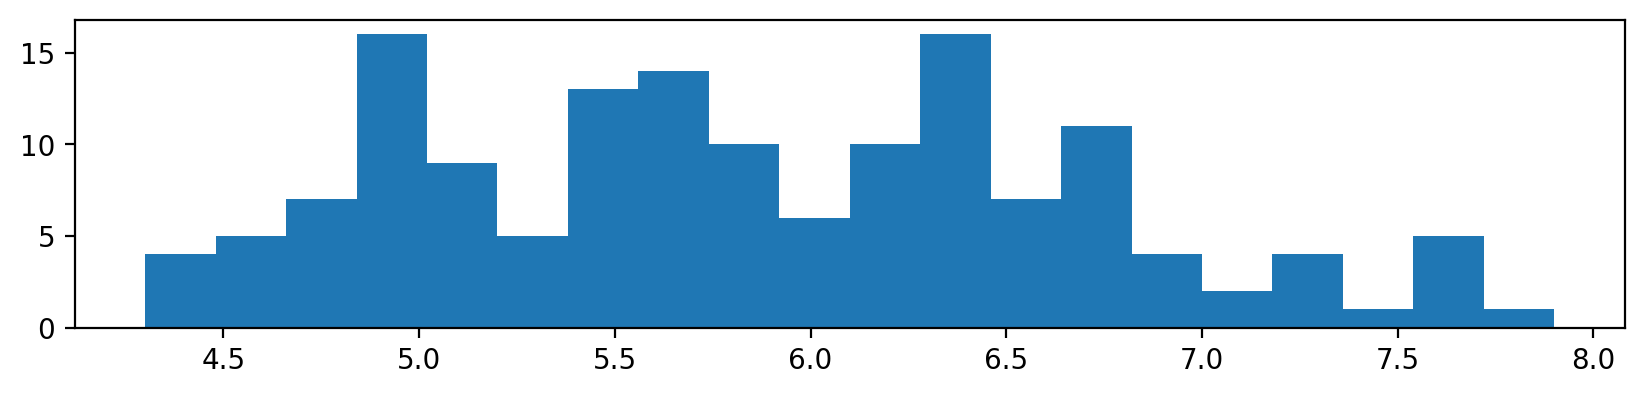

In [95]:
# plt.hist(iris.sepal_length, bins=20, orientation='horizontal') # 가로 histogram
# plt.hist(iris.sepal_length, bins=20, cumulative=True) # 누적 histogram
plt.hist(iris.sepal_length, bins=20)
plt.show()

### 4) axvline(), axhline(), fill(), fill_between()

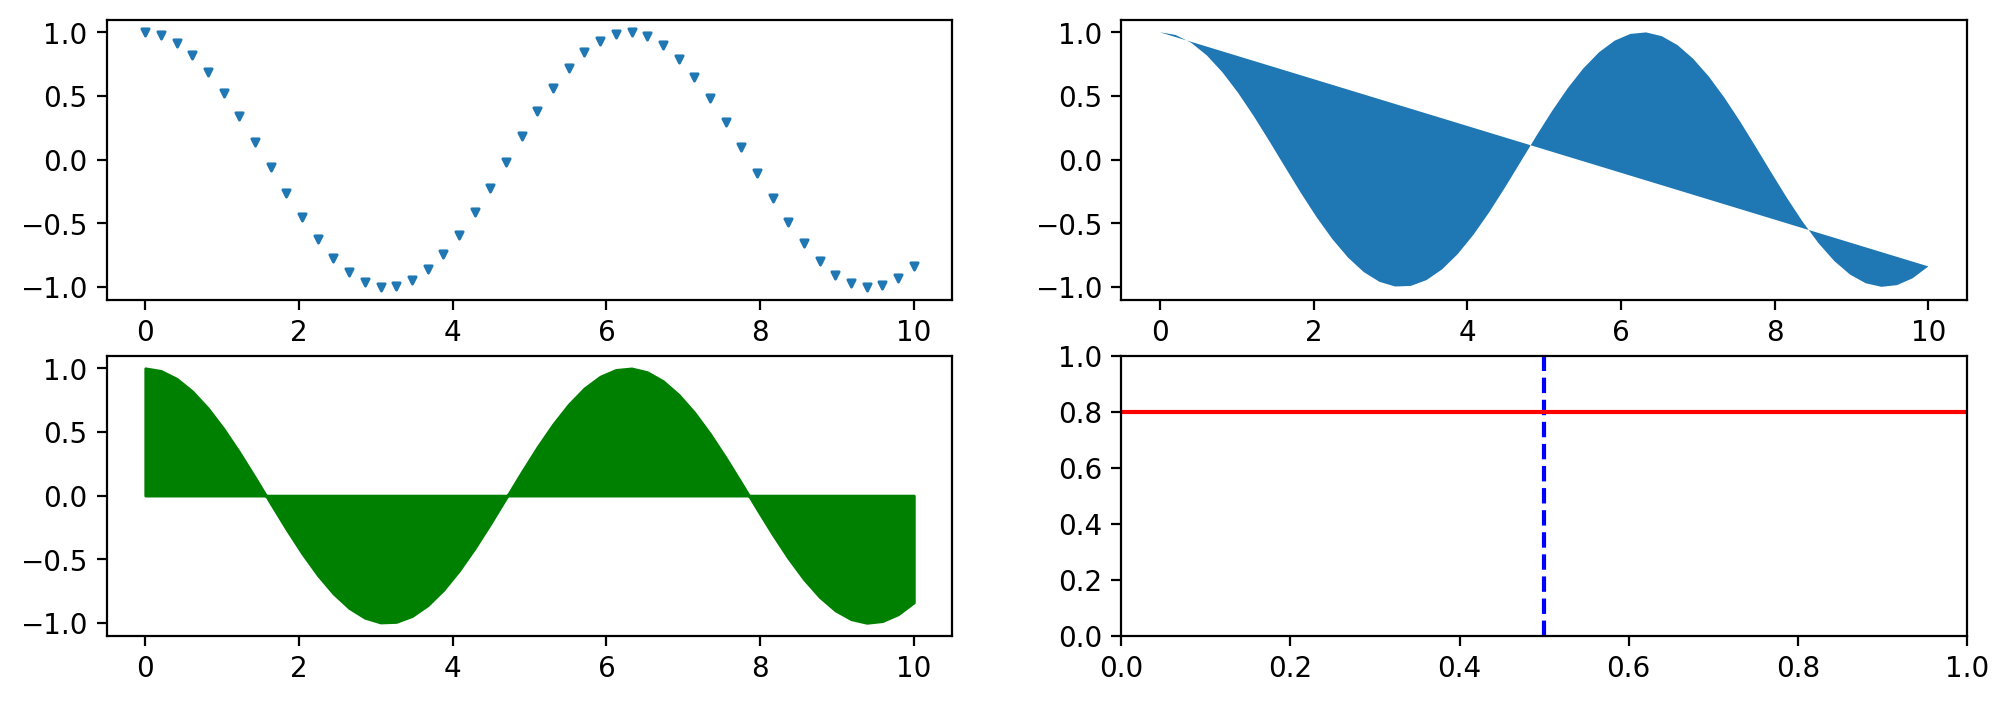

In [87]:
x = np.linspace(0, 10) # 기본값은 50개 데이터 생성
y = np.cos(x)
fig, axes =plt.subplots(2, 2, figsize=(12, 4))
axes[0, 0].scatter(x, y, s=7, marker='v')
axes[0, 1].fill(x, y)
axes[1, 0].fill_between(x, y, color='g')
axes[1, 1].axvline(0.5, c='b', linestyle='--')
axes[1, 1].axhline(0.8, c='r')
plt.show()

###  5) pie

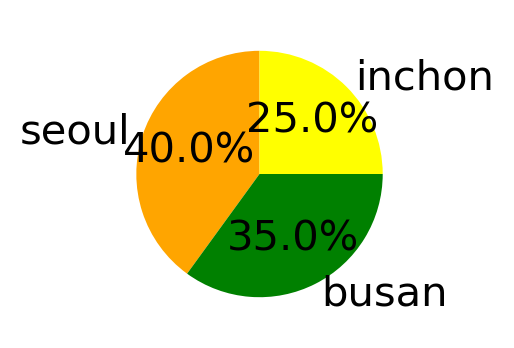

In [94]:
cnt = [40, 35, 25]
labels = ['seoul', 'busan', 'inchon']
colors = ['orange', 'green', 'yellow']
plt.pie(cnt, startangle=90,
        autopct="%.1f%%",
        textprops={'fontsize' : 15},
        labels=labels, colors=colors)
plt.show()

## 1.6 그래프 커스터마이징
### 1) linestyle, linewidth, color, marker...
### 2) text(), annotate()
- 참고 : https://matplotlib.org/api/axes_api.html#text-and-annotations

#### 1. 한글 기본 폰트 설정 방법

In [106]:
plt.rc('font', family='Malgun Gothic') # windows
# plt.rc('font', family='AppleGothic') # MacOS
plt.rc('axes', unicode_minus=False) # 축의 -깨짐 방지

#### 2. 한글 특정 폰트 설정 방법

In [114]:
from matplotlib.font_manager import FontProperties
font_path = 'c:/Windows/Fonts/malgun.ttf'
# 폰트 다운로드 : 네이버, 구글, 산돌, 눈누. ttf파일 다운
font_prop = FontProperties(fname=font_path, size=15)

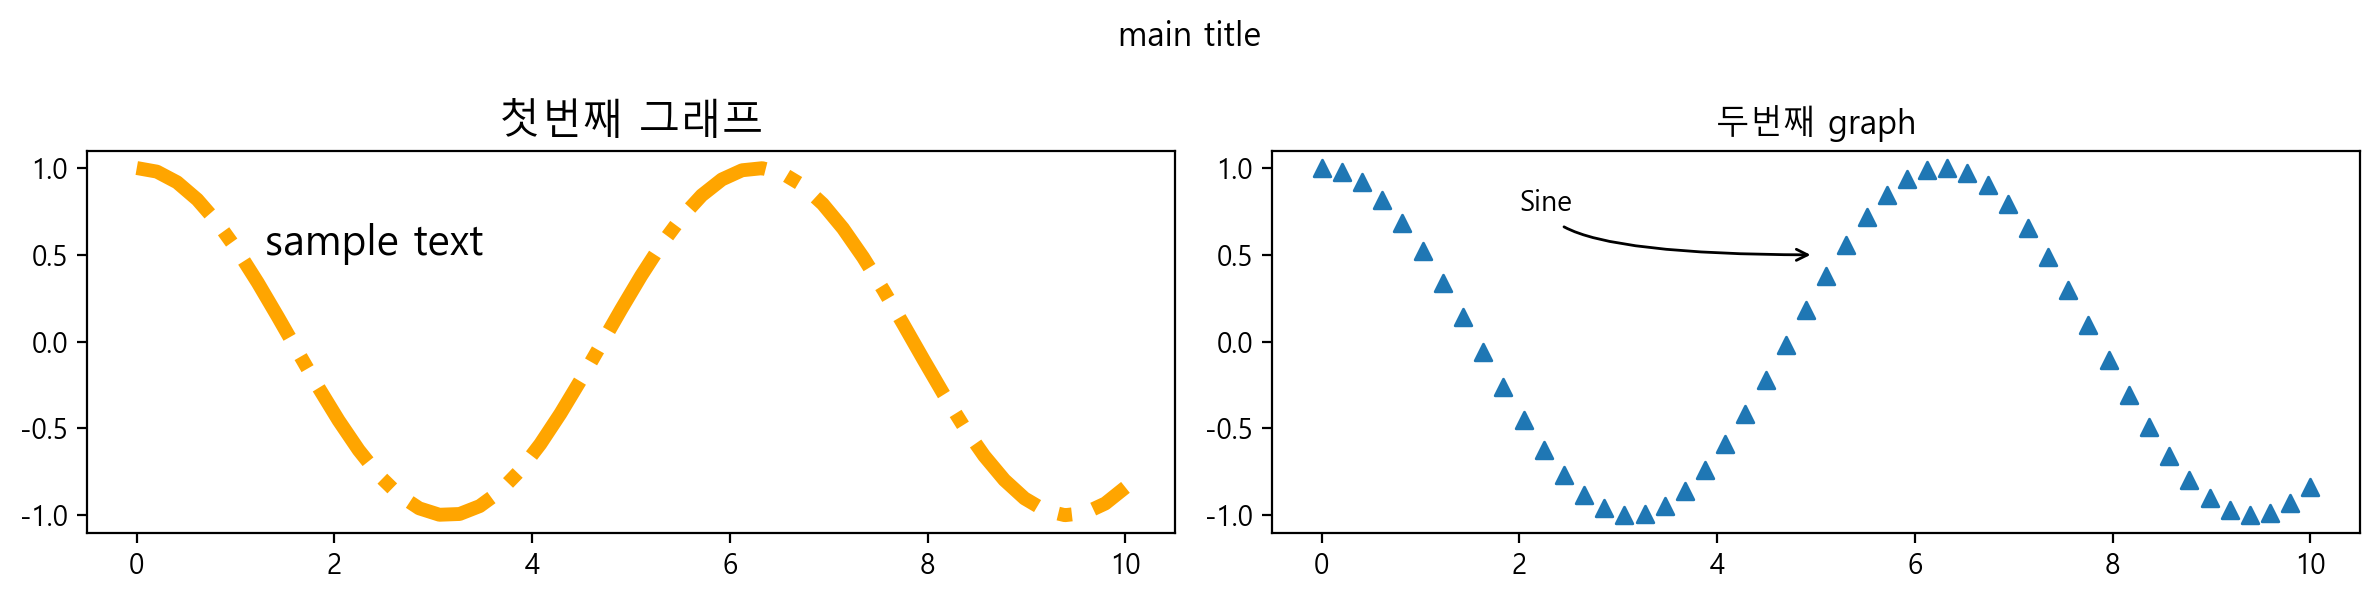

In [116]:
# plt.style.use('ggplot') # default
x = np.linspace(0, 10)
y = np.cos(x)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(x, y, lw=5, ls='-.', c='orange') #
# 택스트 추가
axes[0].text(1.3, 0.5, # 텍스트가 위치할 곳의 좌표
            'sample text',
            fontsize=15)
axes[0].set_title('첫번째 그래프', fontproperties=font_prop)
axes[1].scatter(x, y, marker='^')

# annotate 추가
axes[1].annotate('Sine', xytext=(2, 0.75), # 글자가 있을 좌표(좌표하)
                xy=(5, 0.5), # 화살표가 가리킬 좌표
                arrowprops=dict(arrowstyle='->',
                               connectionstyle='angle3')) # angle, angle3, arc, ...

axes[1].set_title('두번째 graph')
plt.suptitle('main title')
plt.tight_layout()
plt.show()

#### 3. 한글 폰트 설정 방법

- pip install koreanize-matplotlib 후
- import koreanize-matplotlib 한줄이면 보통 NanumGothic으로 셋팅

###  3) 수학기호
- https://matplotlib.org/users/mathtext.html (교안 30p)

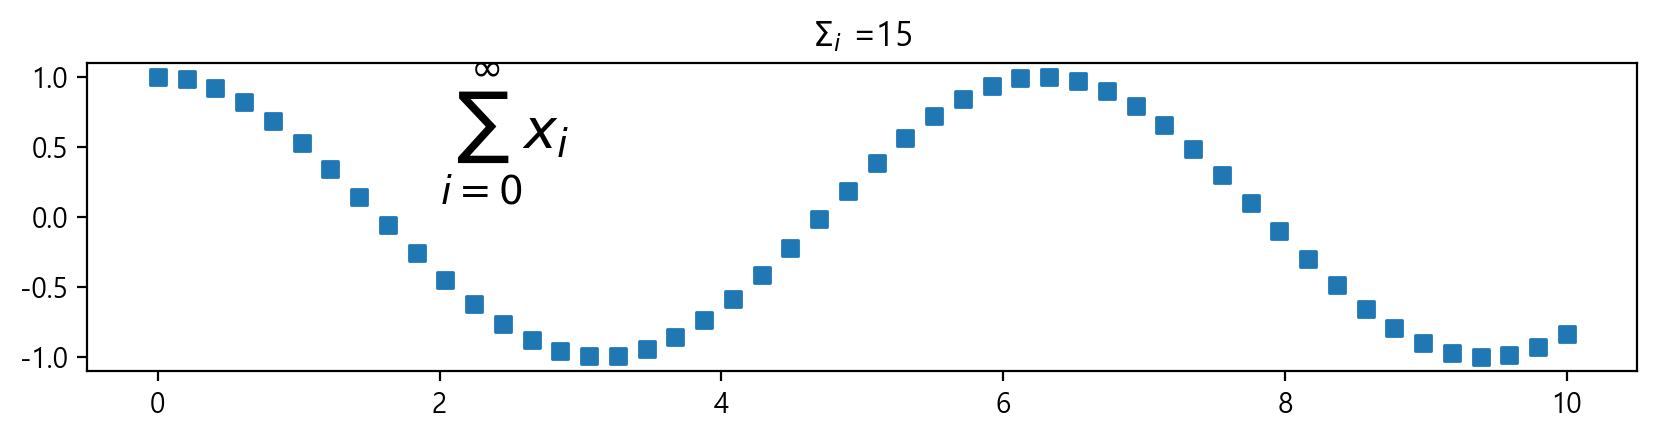

In [121]:
plt.scatter(x, y, marker='s')
plt.title(r'$\Sigma_i$ =15')
plt.text(2, 0.5, r'$\sum_{i=0}^\infty x_i$', fontsize=20)
plt.show()

### 4) 축과 눈금
- https://matplotlib.org/3.1.0/api/axis_api.html (교안 33p)

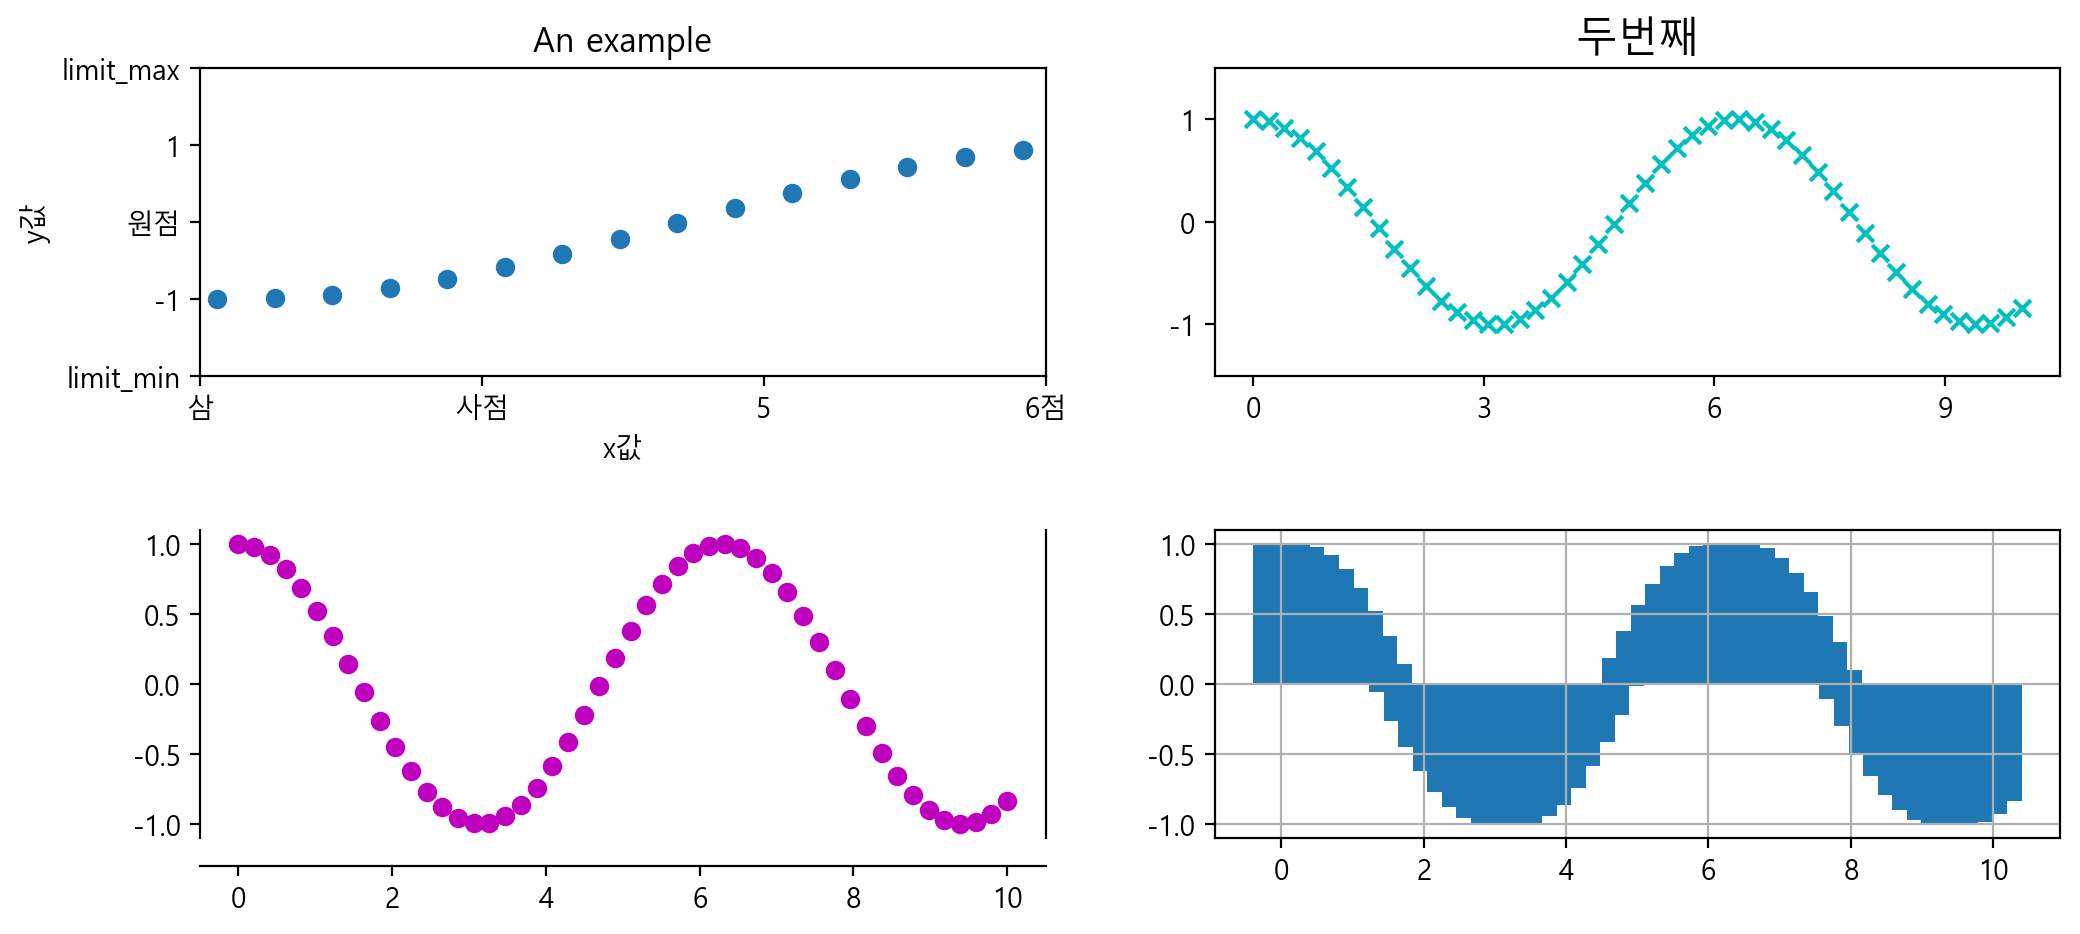

In [127]:
x = np.linspace(0, 10)
y = np.cos(x)

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
# subplot 끼리 여백 조정
plt.subplots_adjust(hspace=0.5) # hspace 위아래 여백(1은 서브플롯 세로높이)
axes[0,0].scatter(x, y)
axes[0,0].set(title='An example',
             ylabel='y값',
             xlabel='x값',
             ylim=[-2, 2], # y축 눈금 범위
             xlim=[3, 6],
             yticks=[-2, -1, 0, 1, 2], # y축 눈금
             yticklabels=['limit_min', -1, '원점', 1, 'limit_max'], # y축 눈금의 라벨
             xticks=[3, 4, 5, 6],
             xticklabels=['삼', '사점', 5, '6점'])
axes[0, 1].scatter(x, y, c='c', marker='x')
axes[0, 1].set_title('두번째', fontsize=15)
axes[0, 1].set_xticks(range(0, 11, 3))
axes[0, 1].set_ylim(-1.5, 1.5)

axes[1, 0].scatter(x, y, c='m')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['bottom'].set_position(('outward', 10)) # 10pt만큼 바깥으로 이동

axes[1, 1].bar(x,y)
axes[1, 1].grid(True)

plt.show()

### 5) 축공유★

In [138]:
import numpy as np
x = np.arange(0, 10)
y1 = 0.5*x**2
y2 = -y1
print(x)
print(y1)
print(y2)

[0 1 2 3 4 5 6 7 8 9]
[ 0.   0.5  2.   4.5  8.  12.5 18.  24.5 32.  40.5]
[ -0.   -0.5  -2.   -4.5  -8.  -12.5 -18.  -24.5 -32.  -40.5]


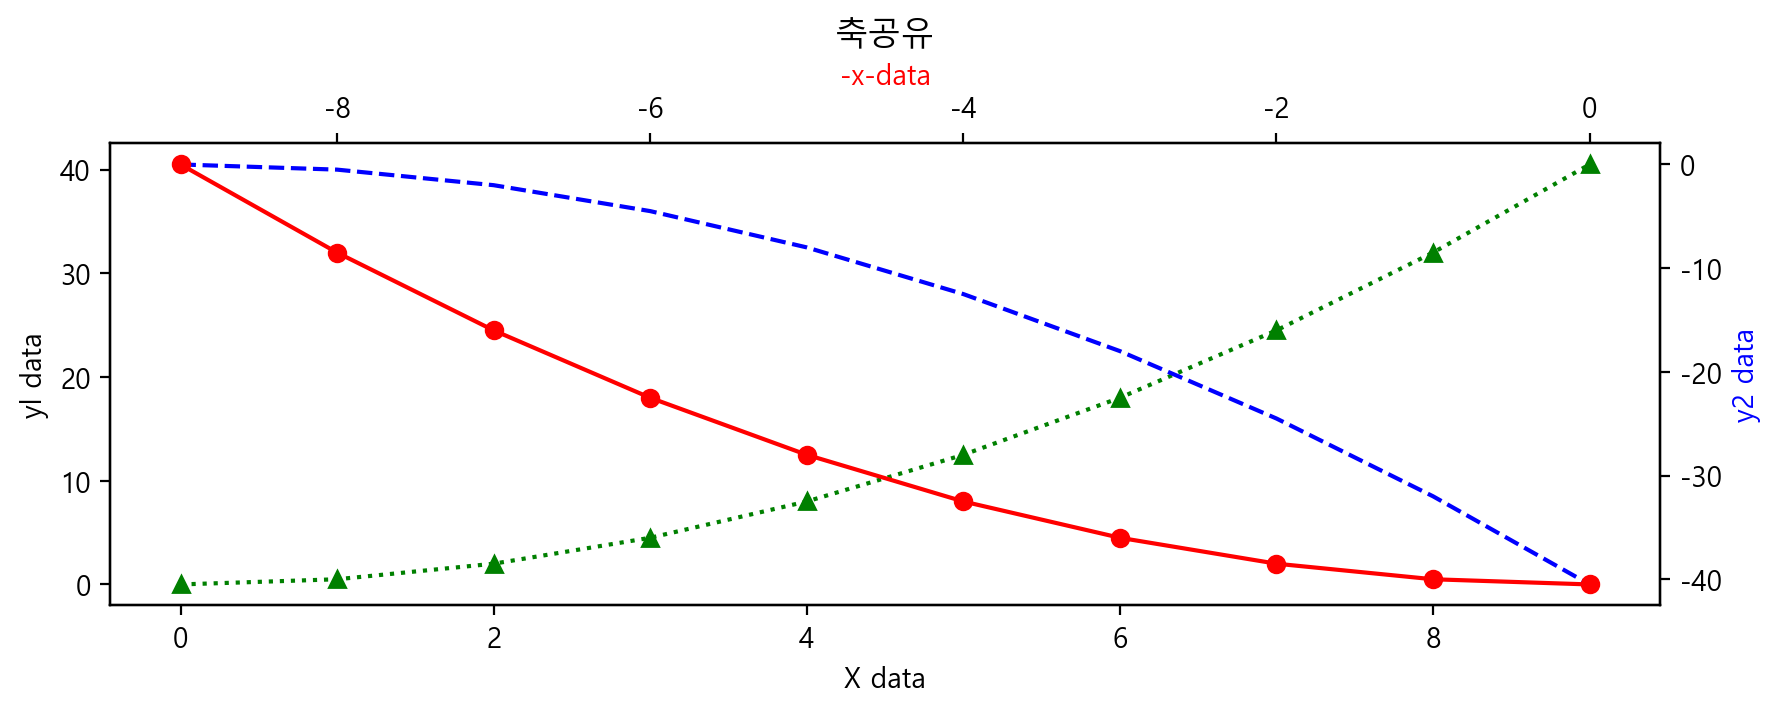

In [139]:
fig, ax1 = plt.subplots(figsize=(10,3))
ax1.plot(x, y1, 'g^:')
ax1.set(title='축공유', xlabel='X data', ylabel='yl data')

ax2 = ax1.twinx() # ax1과 x축을 공유하는 ax2
ax2.plot(x,y2, 'b--')
ax2.set_ylabel('y2 data', color='b')

ax3 = ax1.twiny() #ax1과 y축을 공유하는 ax3
ax3.plot(-x, y1, 'ro-')
ax3.set_xlabel('-x-data', color='r')
plt.show()

### 6) 범례표시
- https://stackoverflow.com/questions/30490740/move-legendoutside-figure-in-seaborn-tsplot

### 7) 플롯 스타일 지정
- 플롯 스타일 지정시 플롯의 기존 설정값이 초기화
    * plt.rc('font', family='Malgun Gothic')
    * plt.rc('axes', unicode_minus=False)

In [ ]:
plt.style.use('ggplot')
# plt.rcParams['figure.figsize']=(12, 3)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정(Win/MacOS)
# plt.rc('font', family='Malgun Gothic') # 윈도우즈
# plt.rc('font', family='AppleGothic') # Mac
# plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게

# 2절. Seaborn
- metplotib기반으로 만든 고수준 그래픽 라이브러리
    * 공식 API 사이트 : 
- Seaborn으로 그래프를 그리기 위해서 다음의 단계를 따른다.
    1) 데이터 준비
    2) 미적 속성 설정
    3) 함수를 이용해서 그래프 그리기(관계형-수치형, 범주형, 쌍관계, 밀도, 회귀, 다중그래프...)
        - 그래프 커스터마이징
    4) 그래프 출력(show), 저장(savefig)

## 2.1 데이터 준비
- iris, titanic

In [140]:
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [141]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [142]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [143]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 2.2 미적 속성 설정(style, context, palette, figsize...)
### 1) 그래프 스타일 지정
- 미적 속성 설정 후, 한글 설정을 다시 실행 
 * plt.rc('font', family='Malgun Gothic') # windows 
 * plt.rc('axes', unicode_minus=False)
 
 * 범례(교안 20p)

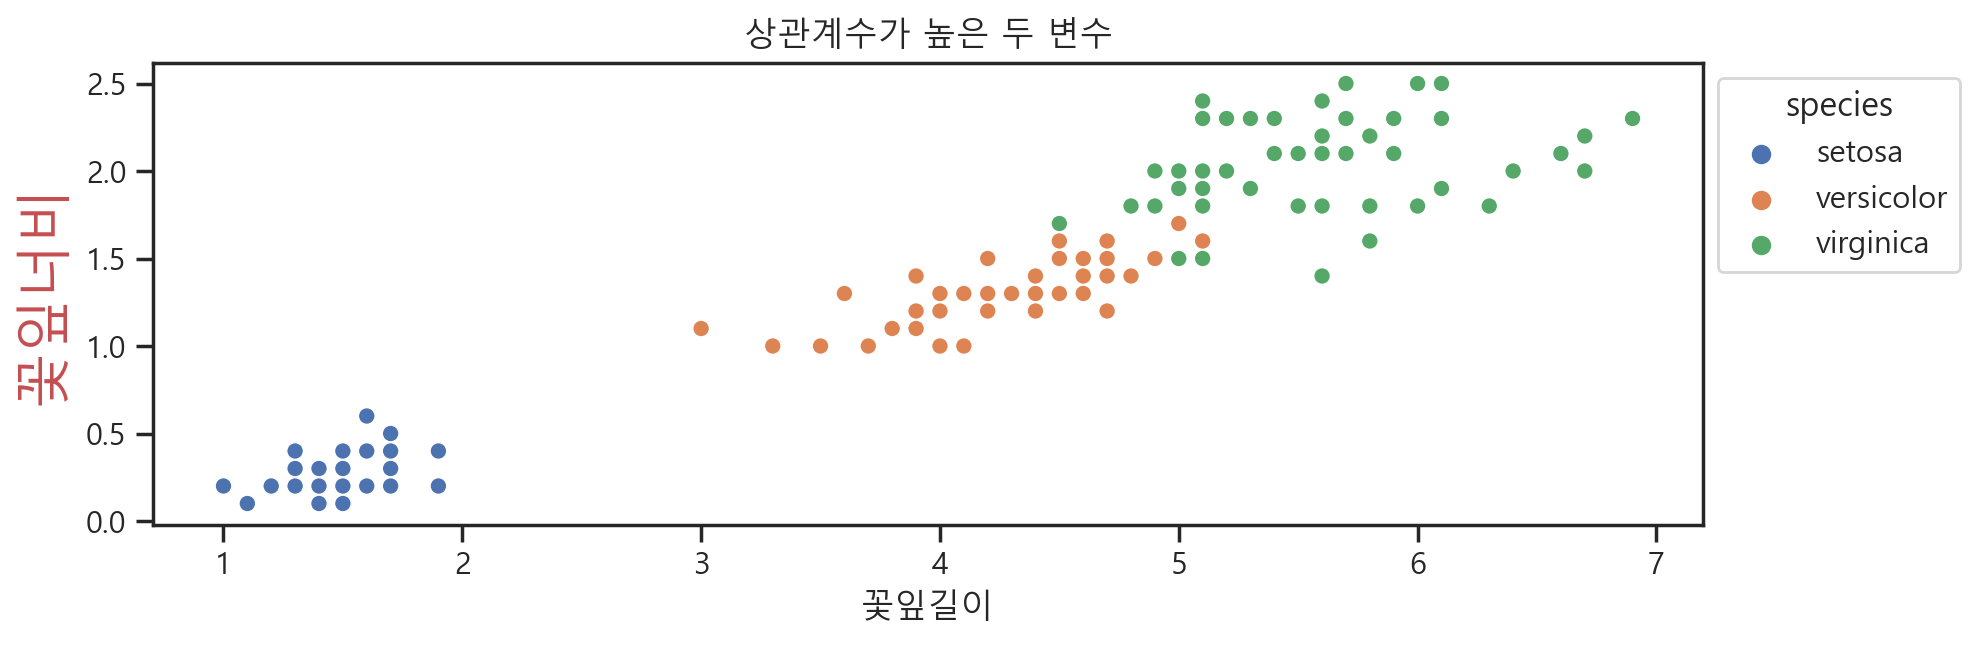

In [157]:
plt.rcParams['figure.figsize'] = (10, 3)
sns.set(style='ticks') # white, darkgrid, whitegrid, dark, ticks
# sns.set_style('whitegrid')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
# plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(title='상관계수가 높은 두 변수',
      xlabel='꽃잎길이',
      ylabel=[1, 3, 5, 7])
ax.set_ylabel('꽃잎너비', fontsize=20, color='r')
plt.show()

### 2) 컨텍스틑 계정(배율)

<function matplotlib.pyplot.show(close=None, block=None)>

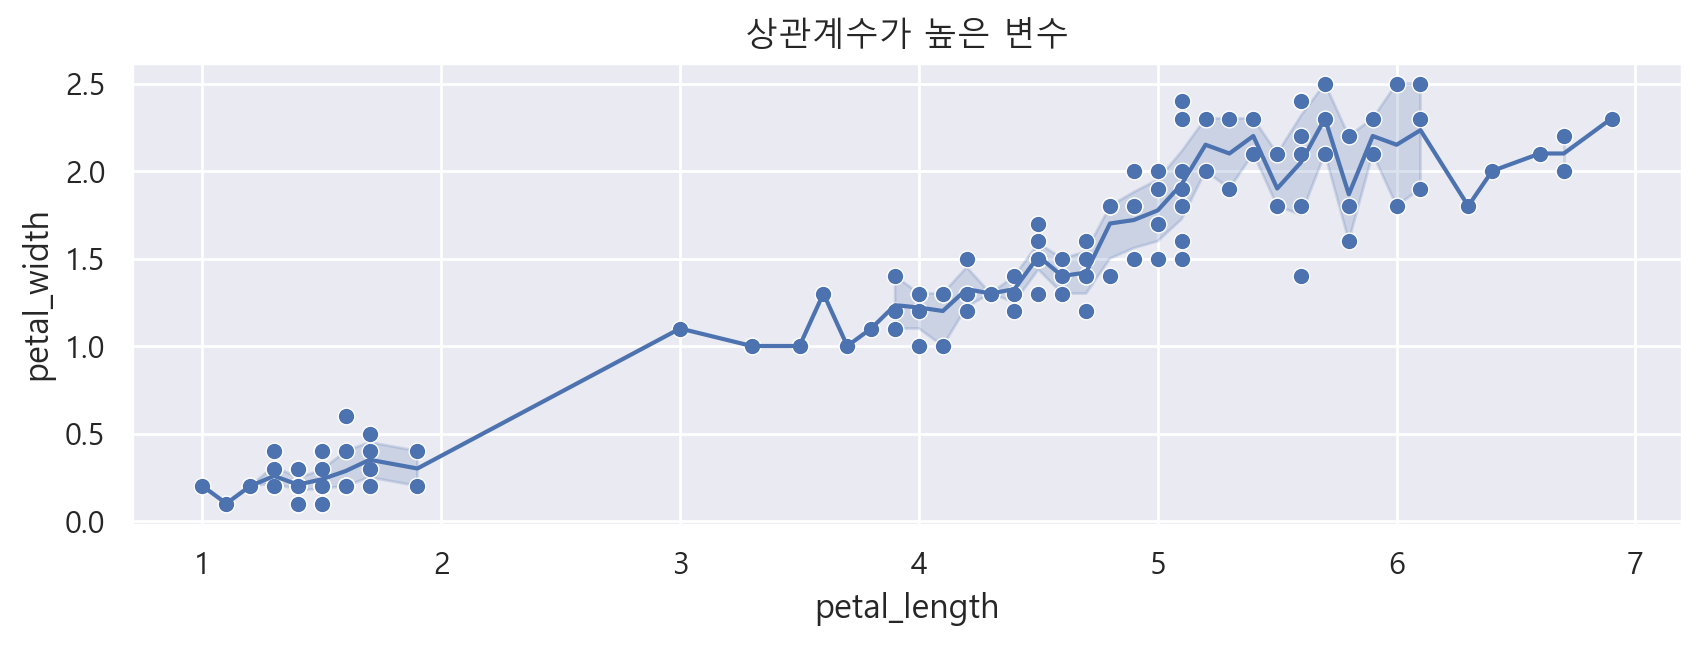

In [155]:
sns.set(context='notebook') #기본값이 'notebook(1.0)', paper(0.8), talk(1.3), paster(1.8)
# sns.set_context('notebook')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

sns.lineplot(data=iris, x='petal_length', y='petal_width')
sns.scatterplot(data=iris, x='petal_length', y='petal_width')
plt.title('상관계수가 높은 변수')
plt.show

### 3) 컬러 팔레트
- https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette
- https://matplotlib.org/tutorials/colors/colormaps.html
- https://seaborn.pydata.org/tutorial/color_palettes.html

In [158]:
sns.set(palette='Pastel1', style='white', context='notebook') # 기본 미적 속성 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
ax = sns.scatterplot(data=iris, x='patel_length', y='patel_width', hue='species')
ax.set(title='상관계수가 높은 두 변수')
ax.set_ylabel('꽃잎너비', fontsize=20, color='r')
plt.show()

ValueError: Could not interpret value `patel_length` for parameter `x`

In [ ]:
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns

# 미속 속성 셋팅
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (12, 3)})

# 한글 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게

In [ ]:
iris = sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')

## 2.3 Seabron 함수로 그래프 그리기
### 1) 관계형 그래프
    - scatterplot, lineplot, replot(서브플롯 제공)

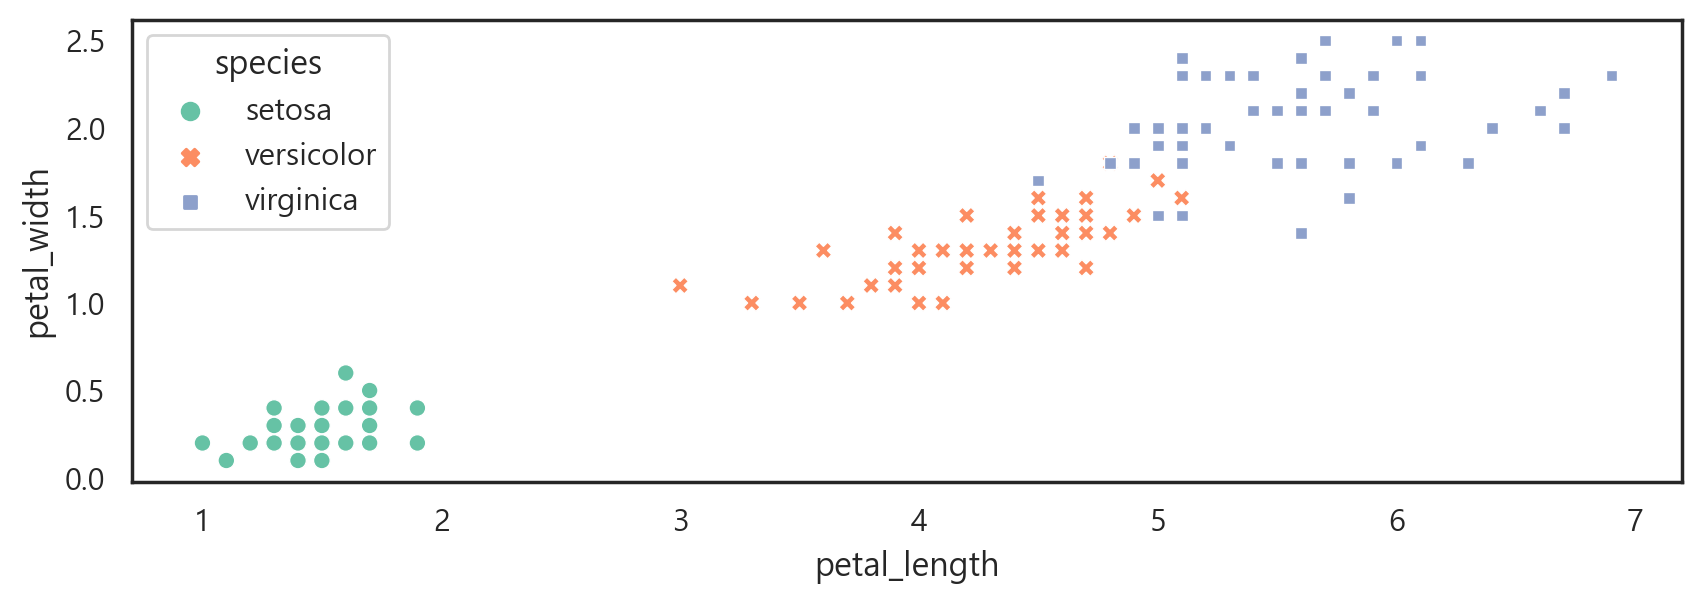

In [163]:
# 종별 다른 색상과 다른 스타일의 scatterplt
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species',
                palette='Set2', style='species')

# sns.scatterplot(data=iris, x=iris.petal_length, y=iris.petal_width, hue=iris.species,
#                palette=iris.Set2, style=iris.species)

plt.show()

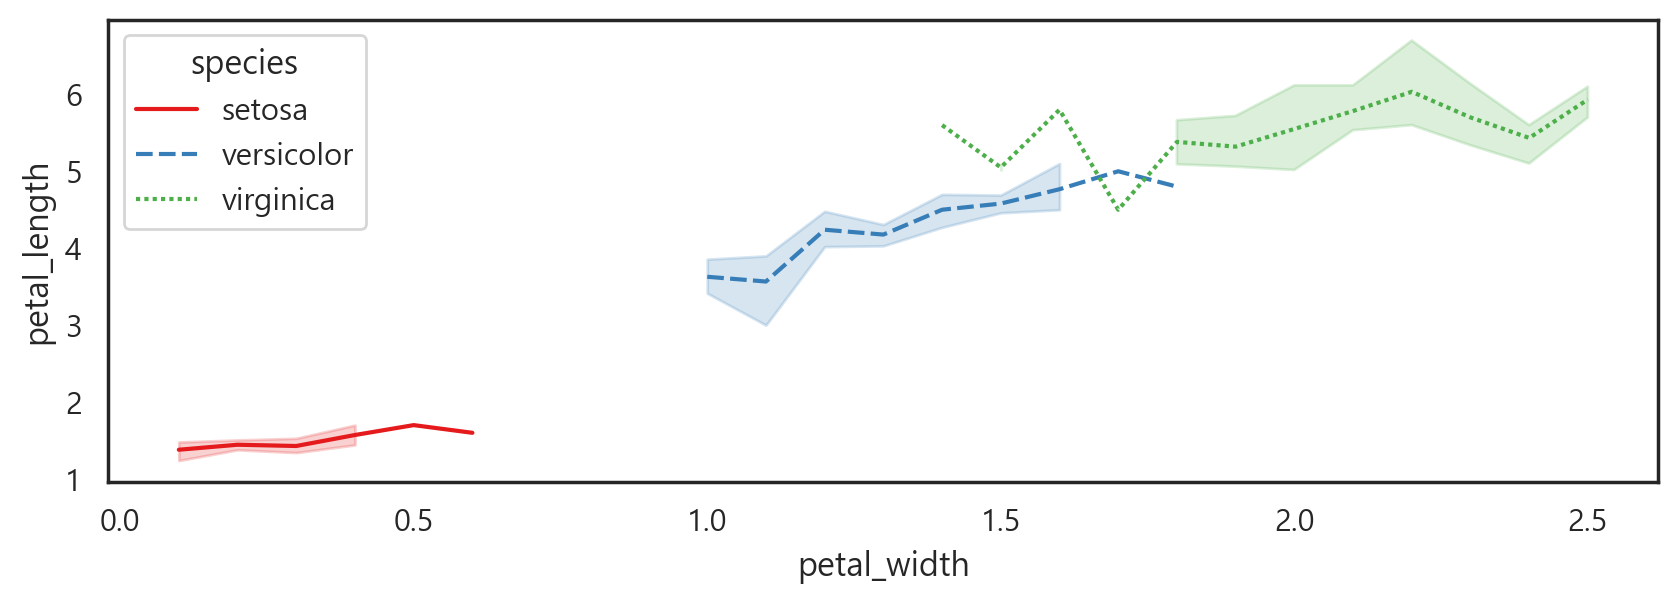

In [167]:
# 종별 다른 색상과 다른 스타일의 lineplot
sns.lineplot(data=iris, x='petal_width', y='petal_length', hue='species', 
             style='species', palette='Set1')

plt.show()

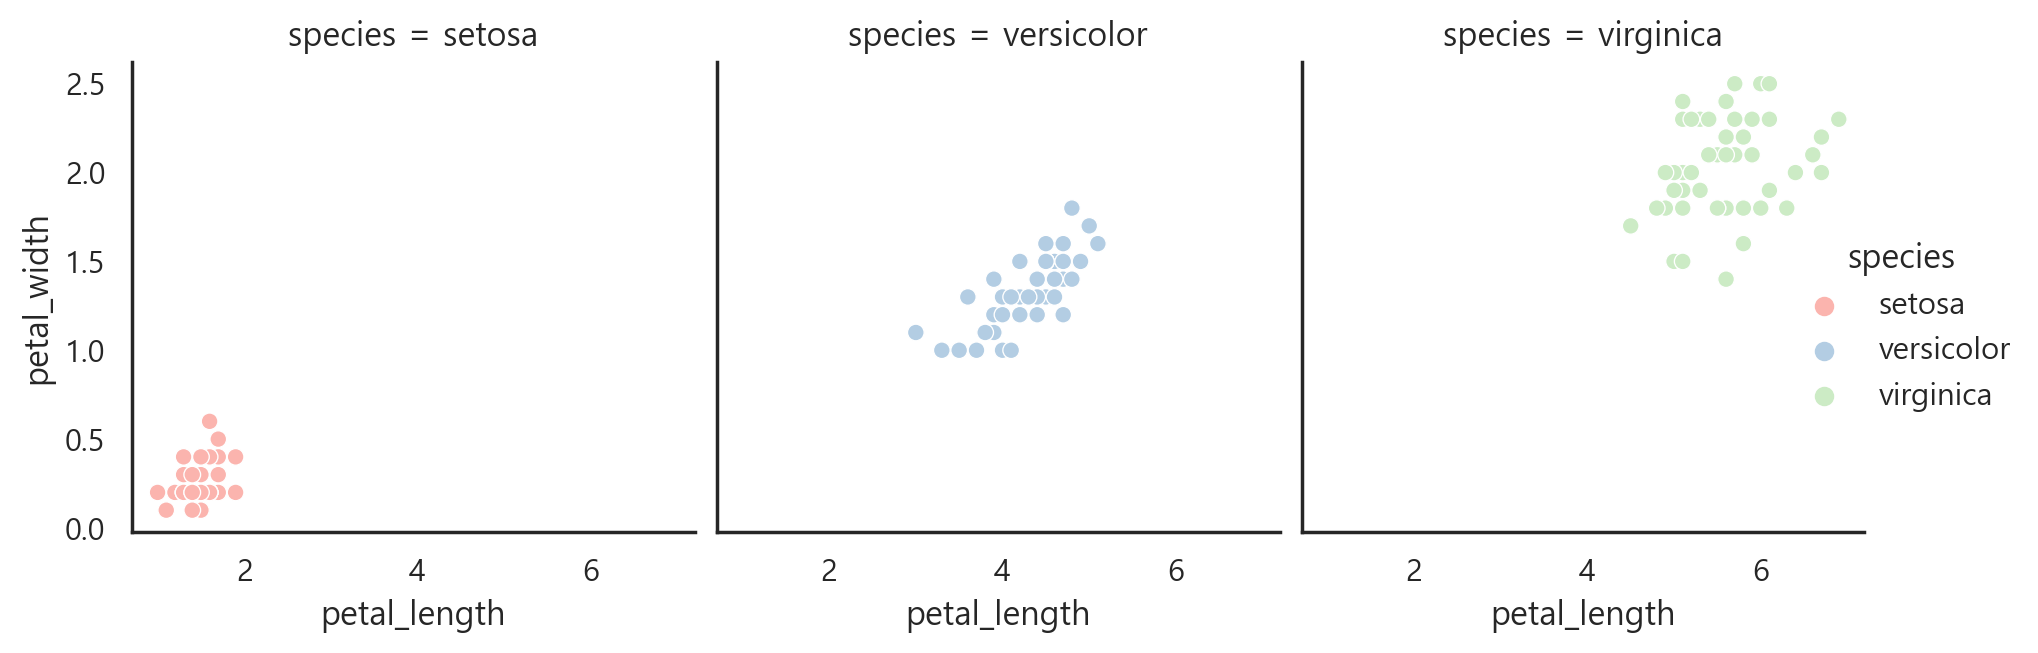

In [176]:
# 종별로 lineplot을 서브블폿으로 → relplot(관계형 그래프에서 서브플롯을 그리는 함수)
g = sns.relplot(data=iris, x='petal_length', y='petal_width', hue='species',
           # 기본값은 kind='scatter',
           col='species', # col 단위로 서브플롯 표현
           # col_wrap=2, # 한줄에 표현될 서브플롯 수
           # facet_kws={'sharey':False, 'sharex':False} # 축 공유 여부
           )
g.fig.set_size_inches(10, 3)
plt.show()

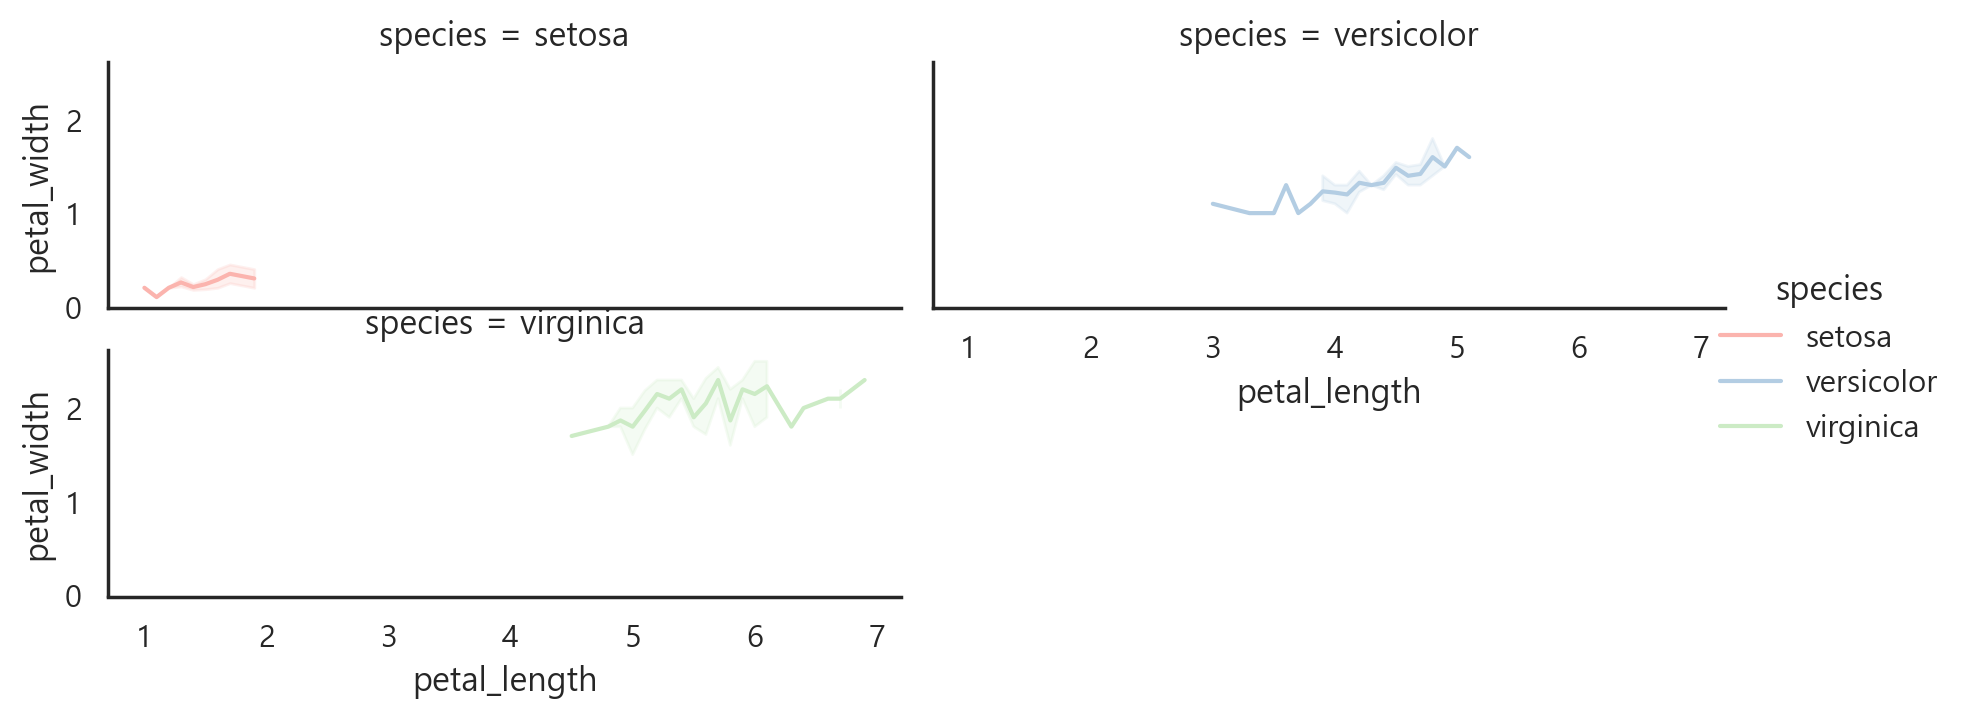

In [177]:
# 종별로 lineplot을 서브블폿으로 → relplot(관계형 그래프에서 서브플롯을 그리는 함수)
g = sns.relplot(data=iris, x='petal_length', y='petal_width', hue='species',
                kind='line',col='species', # col 단위로 서브플롯 표현
                col_wrap=2, # 한줄에 표현될 서브플롯 수
           # facet_kws={'sharey':False, 'sharex':False} # 축 공유 여부
           )
g.fig.set_size_inches(10, 3)
plt.show()

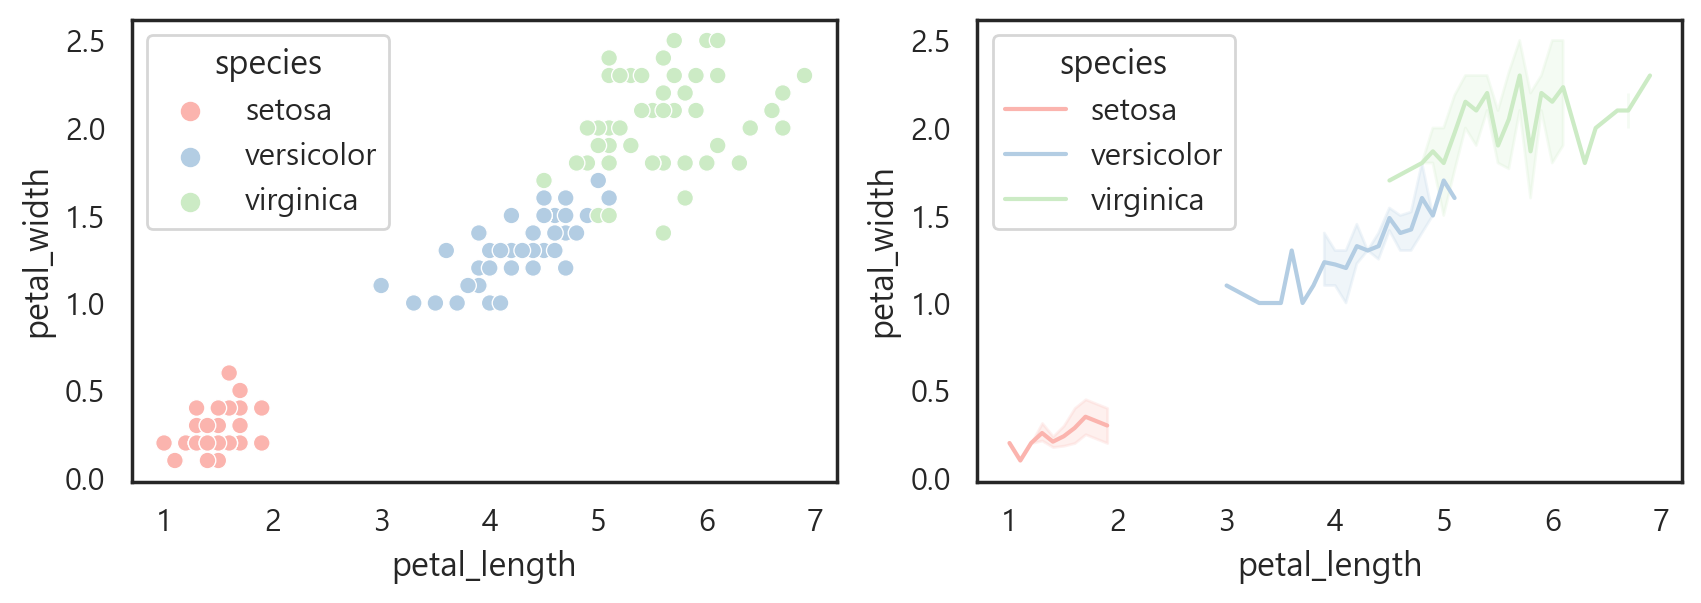

In [178]:
# 서브플롯 : scaterplot, lineplot
fig, ax = plt.subplots(1, 2)
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[0])
sns.lineplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[1])
plt.show()